# Summer project code

## Imports

In [276]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

from scipy.stats import norm
from scipy.special import expit
from scipy.interpolate import interp1d

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, auc, make_scorer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, TunedThresholdClassifierCV
from sklearn.datasets import make_classification
from sklearn.base import BaseEstimator
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import torch

import pickle
from functools import partial

In [7]:
data_sheart = pd.read_csv("data/heart.csv") #https://www.kaggle.com/datasets/yasserh/heart-disease-dataset
data_churn = pd.read_csv("data/employee_churn_dataset.csv") #https://www.kaggle.com/datasets/ziya07/employee-churn-data?
data_heart = pd.read_csv("data/heart_disease_health_indicators_BRFSS2015.csv") #https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset
data_fraud = pd.read_csv("data/transactions_sept_oct_2023.csv") #data science challenge

## Preliminary 

### Real data

In [ ]:
# Modify data_churn 

data_churn = data_churn[data_churn["Gender"]!='Other']
data_churn.drop("Employee ID", inplace=True, axis=1)

gender_map = {"Male": 0, "Female": 1}
education_map = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
marital_map = {"Single": 0, "Married": 1, "Divorced": 2}
jobrole_map = {"Analyst": 0, "Manager": 1, "Sales": 2, "Developer": 3}
department_map = {"HR": 0, "IT": 1, "Sales": 2, "Marketing": 3}
workmode_map = {"Remote": 0, "On-site": 1, "Hybrid": 2}
performance_map = {"Poor": 0, "Average": 1, "Good": 2, "Excellent": 3}

data_churn["Gender"] = data_churn["Gender"].map(gender_map)
data_churn["Education Level"] = data_churn["Education Level"].map(education_map)
data_churn["Marital Status"] = data_churn["Marital Status"].map(marital_map)
data_churn["Job Role"] = data_churn["Job Role"].map(jobrole_map)
data_churn["Department"] = data_churn["Department"].map(department_map)
data_churn["Work Location"] = data_churn["Work Location"].map(workmode_map)
data_churn["Work-Life Balance"] = data_churn["Work-Life Balance"].map(performance_map)

# Modify data_heart
df_pos = data_heart[data_heart.HeartDiseaseorAttack == 1].sample(n=500, random_state=0)
df_neg = data_heart[data_heart.HeartDiseaseorAttack == 0].sample(n=9500, random_state=0)
data_heart = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=0)

In [10]:
def data_overview(data, target):

    print("Length of dataset: ", len(data))
    y = data[target]
    print("Positive class proportion (%): ", np.round(y.mean()*100, 1))
    X = data.drop(target, axis=1)

    # Correlation heatmap
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        data.corr(), 
        cmap='coolwarm',
        fmt=".2f",
        annot=True,
        annot_kws={"size": 7},
    )
    plt.show()

    return np.array(X), np.array(y)

In [ ]:
X_sheart, y_sheart = data_overview(data_sheart, "target")
data_sheart.head(3)

In [ ]:
X_churn, y_churn = data_overview(data_churn, "Churn")
data_churn.head(3)

In [ ]:
X_heart, y_heart = data_overview(data_heart[:10000], "HeartDiseaseorAttack")
data_heart.head(3)

In [ ]:
X_fraud, y_fraud = data_overview(data_fraud, "FLAG_FRAUD")
data_fraud.head(3)

In [15]:
scaler = MinMaxScaler()
X_sheart = scaler.fit_transform(X_sheart)
X_churn = scaler.fit_transform(X_churn)
X_heart = scaler.fit_transform(X_heart)
X_fraud = scaler.fit_transform(X_fraud)

### Synthetic data generation

In [50]:
def generate_dataset(n_samples=10000, n_features=20, p=0.1, random_state=0):
    """
    Generates a binary classification dataset where y depends on X.
    The positive class has proportion ~p.

    Parameters:
        n_samples (int): number of samples in the dataset 
        n_features (int): number of features in the dataset 
        p (float): proportion of positive samples in the dataset, 0<p<1
        seed (int): generator seed

     Returns:
        np.array: generated design matrix
        np.arry: generated target variable
    """

    # Generate X
    rng = np.random.default_rng(random_state)  
    X = rng.standard_normal((n_samples, n_features))

    # Define a true underlying linear model
    weights = rng.standard_normal(n_features)
    logits = X @ weights

    # Shift threshold to control positive rate
    noisy = logits + rng.standard_normal(n_samples)
    threshold = np.percentile(noisy, 100 * (1 - p))
    #threshold = np.percentile(logits, 100 * (1 - p))
    y = (noisy >= threshold).astype(int)

    return X, y

In [18]:
def cross_val_set(X, y, mode="train_test", test_size=0.2, val_size=None, n_splits=5, random_state=0):
    """
    Create train/test splits using either simple train_test or stratified k-fold.

    Parameters:
        X (np.array): design matrix 
        y (np.array): target variable
        mode (str): 'train_test' or 'kfold'
        test_size (float): used if mode='train_test'
        n_splits (int): used if mode='kfold'
        random_state (int): for reproducibility

    Returns:
        - If mode='train_test' and val_size:
            X_train, X_val, X_test, y_train, y_val, y_test
        - If mode='train_test':
            X_train, X_test, y_train, y_test
        - If mode='kfold':
            List of (X_train, X_test, y_train, y_test)
    """

    if mode == "train_test":
        
        if val_size:
            X_temp, X_test, y_temp, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                random_state=random_state
            )
            val_relative = val_size / (1 - test_size)
            X_train, X_val, y_train, y_val = train_test_split(
                X_temp, y_temp,
                test_size=val_relative,
                stratify=y_temp,
                random_state=random_state
            )
            return X_train, X_val, X_test, y_train, y_val, y_test

        else:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                shuffle=True,
                random_state=0
            )
            return X_train, X_test, y_train, y_test

    elif mode == "kfold":
        skf = StratifiedKFold(
            n_splits=n_splits, 
            shuffle=True, 
            random_state=0)
        folds = [
            (X[train_idx], X[test_idx], y[train_idx], y[test_idx])
            for train_idx, test_idx in skf.split(X, y)
        ]
        return folds
    
    else:
        raise ValueError("mode should be 'train_test' or 'kfold'")

In [51]:
X_01, y_01 = generate_dataset()
X_train_01, X_test_01, y_train_01, y_test_01 = cross_val_set(X_01, y_01)
print(np.mean(y_01))
print(np.mean(y_train_01))
print(np.mean(y_test_01))

0.1
0.1
0.1


In [52]:
X_05, y_05 = generate_dataset(p=0.5)
X_train_05, X_test_05, y_train_05, y_test_05 = cross_val_set(X_05, y_05)
X_005, y_005 = generate_dataset(p=0.05)
X_train_005, X_test_005, y_train_005, y_test_005 = cross_val_set(X_005, y_005)
X_002, y_002 = generate_dataset(p=0.02)
X_train_002, X_test_002, y_train_002, y_test_002 = cross_val_set(X_002, y_002)
X_001, y_001 = generate_dataset(p=0.01)
X_train_001, X_test_001, y_train_001, y_test_001 = cross_val_set(X_001, y_001)

X_xs, y_xs = generate_dataset(n_samples=100)
X_train_xs, X_test_xs, y_train_xs, y_test_xs = cross_val_set(X_xs, y_xs)
X_s, y_s = generate_dataset(n_samples=1000)
X_train_s, X_test_s, y_train_s, y_test_s = cross_val_set(X_s, y_s)
X_m, y_m = generate_dataset(n_samples=10000)
X_train_m, X_test_m, y_train_m, y_test_m = cross_val_set(X_m, y_m)
X_l, y_l= generate_dataset(n_samples=100000)
X_train_l, X_test_l, y_train_l, y_test_l = cross_val_set(X_l, y_l)

X_train_sheart, X_test_sheart, y_train_sheart, y_test_sheart = cross_val_set(X_sheart, y_sheart)
X_train_churn, X_test_churn, y_train_churn, y_test_churn = cross_val_set(X_churn, y_churn)
X_train_heart, X_test_heart, y_train_heart, y_test_heart = cross_val_set(X_heart, y_heart)
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = cross_val_set(X_fraud, y_fraud)

### SQBC class

In [133]:
class SQBC(BaseEstimator):

    def __init__(self, n_estimators=100, alpha=0.5, 
                 tau=0.5, eta=0.1, h=0.1, t=0, 
                 random_state=0, base_learner="tree"):
        if not 0 < tau < 1:
            raise ValueError("tau must be between 0 and 1")
        if base_learner not in ["tree", "OLS"]:
            raise ValueError("base_learner must be 'tree' or 'OLS'")
        self.n_estimators = n_estimators
        self.alpha = alpha
        self.tau = tau
        self.eta = eta
        self.h = h
        self.t = t
        self.random_state = random_state
        self.base_learner = base_learner
        self.models = []
        self.loss_history = []
    

    def compute_loss(self, X, y):
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        Kf = norm.cdf(f/self.h)
        loss = self.tau * (y - Kf) + self.alpha * np.log1p(np.exp(-(y - Kf) / self.alpha))
        return np.mean(loss)
    

    def fit(self, X, y, verbose=False):
        f = np.zeros(len(y))
        self.models = []
        self.loss_history = []

        for m in range(self.n_estimators):

            Kf = norm.cdf(f/self.h)
            K_prime_f = norm.pdf(f/self.h) / self.h
            U = -K_prime_f * (1/(1 + np.exp((y - Kf)/self.alpha)) - self.tau)
            
            if self.base_learner=="tree":
                model = DecisionTreeRegressor(max_depth=1,random_state=self.random_state)
            elif self.base_learner=="OLS":
                model = LinearRegression()

            model.fit(X, U)
            self.models.append(model)
            f += self.eta * model.predict(X)

            # Keep loss
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)
            if (m % 10 == 0) and verbose:
                print(f"Iter {m}, loss = {loss:.4f}")

    
    # Predict quantile of Y*
    def predict_quantile(self, X):
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        return f
    

    # Predict Y by thresholding quantile of Y*
    def predict(self, X):
        if not self.models:
            raise ValueError("Model has not been fitted yet.")
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        return (f >= self.t).astype(int)
    
    
    def get_params(self, deep=True):
        return {
            "n_estimators": self.n_estimators,
            "alpha": self.alpha,
            "tau": self.tau,
            "eta": self.eta,
            "h": self.h,
            "t": self.t,
            "base_learner": self.base_learner
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self
    

    def plot_loss(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.loss_history, label="Loss")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training Loss per Iteration")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

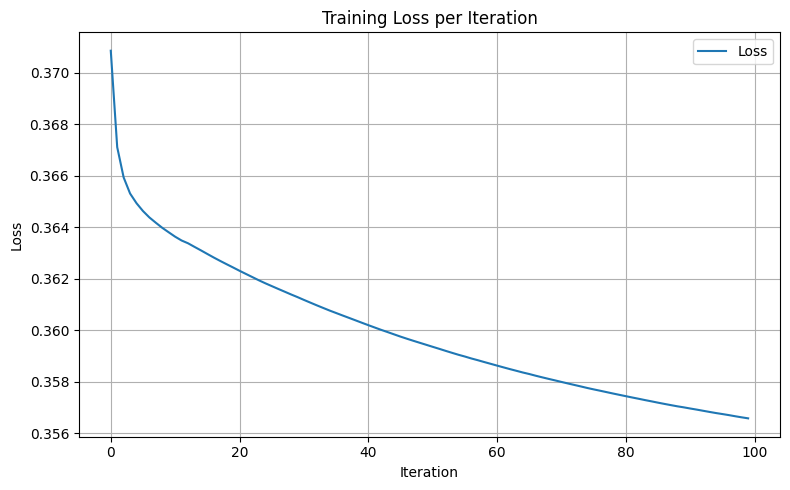

In [579]:
model = SQBC()
model.fit(X_train_01, y_train_01)
model.plot_loss()

### Classification evaluation

In [21]:
# Define personnalized metrics 
 
def specificity_score(y_true, y_pred):
    """
    Computes specificity of classification.

    Parameters: 
        y_true (np.array): true value of target variable
        y_pred (np.array): predicted value of target  variable

    Returns:
    float: specificity score
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    return specificity


def cost_score(y_true, y_pred, cost_10=10, cost_01=100, cost_11=10, cost_00=0, normalize=True):
    """
    Computes total cost of classification based on cost matrix.
    Return:
        float: opposite of total coast
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fp*cost_10 + fn*cost_01 + tp*cost_11 + tn*cost_00

    if normalize==True:
        FP = (y_true == 0).sum()
        FN = (y_true == 1).sum()
        max_cost = FP*cost_10 + FN*cost_01 
        total_cost = total_cost / max_cost if max_cost > 0 else 0.0
        
    return -total_cost

In [278]:
def evaluate(y_true, y_pred, y_scores=None, cost_10=10, cost_01=100, cost_11=10, cost_00=0, plot=True):
    """
    Returns and plots classification results.

    Parameters: 
        y_true (np.array): true value of target variable
        y_pred (np.array): predicted value of target  variable

    Returns:
        dictionary: evaluation metrics
    """  
    acc = accuracy_score(y_true, y_pred)
    #roc = roc_auc_score(y_true, y_pred)
    #w_acc = balanced_accuracy_score(y_true, y_pred) # harmonic mean of recall and specificty
    rec = recall_score(y_true, y_pred, zero_division=0) 
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = specificity_score(y_true, y_pred)
    """
    cost = -cost_score(y_true, y_pred, 
                        cost_10=cost_10, cost_01=cost_01, 
                        cost_11=cost_11, cost_00=cost_00
                    )
    """
    #roc_auc = None
    #pr_auc = None
    #if y_scores.all(): 
    roc_auc = roc_auc_score(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    metrics = {
            "f1": round(f1, 2),
            "roc_auc": round(roc_auc, 2),
            "pr_auc": round(pr_auc, 2),
            "accuracy": round(acc, 2),
            #"balanced_accuracy": round(w_acc, 2),
            "recall": round(rec, 2),
            "precision": round(prec, 2),
            "specificity": round(spec, 2),
            #"cost": round(cost, 2)
        }
    
    if plot:
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot()
        plt.show()

        print(metrics)
    
    return metrics 

In [ ]:
y_pred_01 = model.predict(X_test_01)
metrics = evaluate(y_test_01, y_pred_01)

### State-of-art models

State of the art models are XGBoost algorithm with different loss functions, adpated to imbalance classification. They will all implement threshold optimization.

In [272]:
def train_eval_sota_model(
        X_train, y_train, X_test, y_test, base_model, 
        opt_metric="f1", opt_thresh=False, 
        thresholds = np.linspace(0, 1, 201)
    ): 
    """
    Train state-of-the-art model with threshold optimization.
    """

    if opt_thresh == True: 

        if opt_metric == "precision":
            opt_metric = make_scorer(precision_score, zero_division=0)

        clf = TunedThresholdClassifierCV(
            estimator=base_model,
            scoring=opt_metric,
            thresholds=thresholds
        )
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:,1]
        metrics = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics["Threshold"] = round(clf.best_threshold_, 2)

    else: 
        base_model.fit(X_train, y_train)
        y_pred = base_model.predict(X_test)
        y_prob = base_model.predict_proba(X_test)[:,1]
        metrics = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics["Threshold"] = 0.5

    return metrics


In [169]:
def pipeline_sota(
        X_train, y_train, X_test, y_test, opt_metric="f1",
        verbose=True, opt_thresh=False,
        models={
            'XGBoost': xgb.XGBClassifier(),
            'LightGBM': lgb.LGBMClassifier(),
            'CatBoost': CatBoostClassifier(verbose=0),
            'Random_Forest': RandomForestClassifier(),
            'Logistic_Regression': LogisticRegression(max_iter=1000)
        }
    ):
    """
    Compares multiple XGBoost variants with thresholds optimized for a single metric.
    Displays a summary table of all metrics evaluated at that optimal threshold.
    """
    list_metrics = []

    for name, base_model in models.items():
        
        if verbose:
            print(f"\nTraining {name}")

        metrics = train_eval_sota_model(
            X_train, y_train, X_test, y_test, base_model, 
            opt_metric=opt_metric, opt_thresh=opt_thresh
        )
        list_metrics.append(metrics)

    return list_metrics 

In [243]:
soa_metrics_05 = pipeline_sota(X_train_05, y_train_05, X_test_05, y_test_05)
soa_metrics_01 = pipeline_sota(X_train_01, y_train_01, X_test_01, y_test_01)
soa_metrics_005 = pipeline_sota(X_train_005, y_train_005, X_test_005, y_test_005)
soa_metrics_002 = pipeline_sota(X_train_002, y_train_002, X_test_002, y_test_002)
soa_metrics_001 = pipeline_sota(X_train_001, y_train_001, X_test_001, y_test_001)

soa_metrics_sheart = pipeline_sota(X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart)
soa_metrics_churn = pipeline_sota(X_train_churn, y_train_churn, X_test_churn, y_test_churn)
soa_metrics_heart = pipeline_sota(X_train_heart, y_train_heart, X_test_heart, y_test_heart)
soa_metrics_fraud = pipeline_sota(X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud)

resultats = {
    "soa_metrics_05": soa_metrics_05,
    "soa_metrics_01": soa_metrics_01,
    "soa_metrics_005": soa_metrics_005,
    "soa_metrics_002": soa_metrics_002,
    "soa_metrics_001": soa_metrics_001,
    "soa_metrics_sheart": soa_metrics_sheart,
    "soa_metrics_churn": soa_metrics_churn,
    "soa_metrics_heart": soa_metrics_heart,
    "soa_metrics_fraud": soa_metrics_fraud
}

with open("resultats_sota.pkl", "wb") as f:
    pickle.dump(resultats, f)


Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression

Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression

Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression

Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression

Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression

Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression

Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression

Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression

Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression


## Optimal cost

Specific part for optimizing the cost metric. In that case, we know that the optimal threshold is: 
$$p^* = \frac{C(1,0) - C(0,0)}{C(1,0)-C(0,0)+C(0,1)-C(1,1)} = 1 - \tau.$$
Which yields an optimal $\tau$:
$$\tau^* = \frac{C(0,1)-C(1,1)}{C(1,0)-C(0,0)+C(0,1)-C(1,1)}.$$

In [ ]:
def cost_vs_tau_plot_bootstrap(X, y, 
                     cost_10=10, cost_01=100, cost_11=10, cost_00=0,
                     tau_range=np.arange(0.01, 1, 0.05),
                     n_bootstrap=5, test_size=0.3,
                     n_estimators=100, alpha=0.5, 
                     eta=0.1, h=0.1, t=0, 
                     random_state=0, base_learner="tree"):
    """
    Bootstrap version: average total cost for each tau value over bootstrap samples.
    """
    all_costs = []

    for b in range(n_bootstrap):
        print(f"Bootstrap step {b+1}")
        
        X_boot, y_boot = resample(X, y)
        X_train, X_test, y_train, y_test = train_test_split(
            X_boot, y_boot, test_size=test_size, stratify=y_boot
            )

        costs = []
        for tau in tau_range:
            model = SQBC(
                        n_estimators=n_estimators, alpha=alpha, 
                        tau=tau, eta=eta, h=h, t=t, 
                        random_state=random_state, base_learner=base_learner
                    )
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            cost = -cost_score(y_test, y_pred, cost_10, cost_01, cost_11, cost_00)
            costs.append(cost)
        all_costs.append(costs)

    all_costs = np.array(all_costs)
    avg_costs = np.mean(all_costs, axis=0)
    std_costs = np.std(all_costs, axis=0)
    print(tau_range)
    print(avg_costs - std_costs)
    print(avg_costs + std_costs)

    # Theoretical tau*
    p_star = (cost_10 - cost_00) / (cost_10 - cost_00 + cost_01 - cost_11)
    tau_star = 1 - p_star

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(tau_range, avg_costs, 'b-o', label='Avg Cost')
    if not np.allclose(avg_costs - std_costs, avg_costs + std_costs):
        plt.fill_between(
            tau_range,
            avg_costs - std_costs,
            avg_costs + std_costs,
            color='blue',
            alpha=0.2,
            label="±1 std"
            )
    plt.axvline(x=tau_star, color='red', linestyle='--', label=r'Theoretical $\tau^*$')
    plt.xlabel(r'Quantile level $\tau$')
    plt.ylabel('Total Cost')
    plt.title('Total Cost vs Threshold τ (with Bootstrap)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout(rect=[0, 0.05, 1, 1]) 
    plt.show()


Bootstrap step 1
Bootstrap step 2
Bootstrap step 3
Bootstrap step 4
Bootstrap step 5


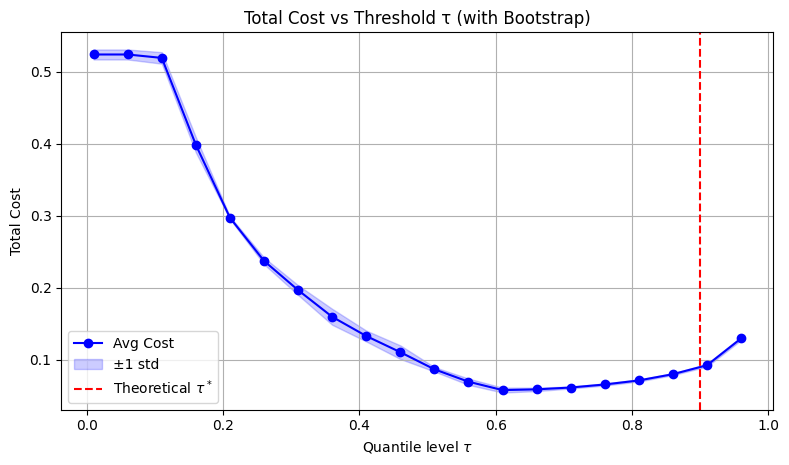

In [ ]:
cost_vs_tau_plot_bootstrap(X_01, y_01)

Divergence between theory and practice => to explain. The cost will therefore be optimized similarly to other metrics. 

In [ ]:
cost_vs_tau_plot_bootstrap(X_churn, y_churn)

## Effect of $\tau$ on metrics at different imbalance degrees

In [255]:
def plot_metrics_vs_tau_for_imbalances(
        imbalances=[0.5, 0.2, 0.1, 0.05, 0.01], 
        tau_range=np.linspace(0.1, 1, 15, endpoint=False),
        nb_cols=2, 
        cost_10=10, cost_01=100, cost_11=10, cost_00=0
    ):
    """
    For each imbalance level in `imbalances`, plot metric curves as a function of τ (with denser sampling after 0.5),
    and highlight the τ that minimizes cost.
    """
    metrics_names = [
        "f1",  "accuracy", 
        "recall", "precision", "specificity"
    ]
    n_imbalances = len(imbalances)

    # Prepare subplots
    total_plots = n_imbalances + 1 # one subplot for legend
    n_col = min(nb_cols, total_plots)
    n_row = total_plots//n_col + (total_plots%n_col > 0)

    fig, axes = plt.subplots(n_row, n_col, figsize=(15, 4*n_row), sharey=True)
    axes = axes.flatten()

    colors = plt.cm.get_cmap('tab10', len(metrics_names))

    for id, p in enumerate(imbalances):

        print('\nImbalance degree: ', p)

        X, y = generate_dataset(p=p)
        X_train, X_test, y_train, y_test = cross_val_set(X, y)

        metric_curves = {m: [] for m in metrics_names}

        for tau in tau_range:

            #print('Tau value: ', tau)

            # Fit model
            model = SQBC(tau=tau)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Retrieve metrics 
            metrics = evaluate(y_test, y_pred, cost_10, cost_01, cost_11, cost_00, plot=False)
            for m in metrics_names:
                metric_curves[m].append(metrics[m])

        # Plot metrics
        ax = axes[id]
        for i, m in enumerate(metrics_names):
            values = metric_curves[m]
            ax.plot(tau_range, values, linestyle='--', marker='o', markersize=4, color=colors(i), label=m)
            # Higlight best tau
            best_idx = np.argmin(values) if m=='cost' else np.argmax(values)
            best_tau = tau_range[best_idx]
            ax.plot(best_tau, values[best_idx], marker='^', markersize=10, color=colors(i))

        ax.set_title(f"P(Y=1) = {p}")
        ax.set_xlabel(r"Quantile level $\tau$")
        if id % n_col == 0:
            ax.set_ylabel("Metric value")
        ax.grid(True)

    # Subplot for legend 
    legend_ax = axes[id+1]
    legend_ax.axis('off') 
    handles, labels = axes[0].get_legend_handles_labels()
    legend_ax.legend(handles, labels, loc='upper center', fontsize=12, ncol=2, frameon=False)

    # Delete empty plots
    for j in range(n_imbalances+1, n_row * n_col):
        fig.delaxes(axes[j])

    plt.suptitle("Metric evolution according to τ with best τ per metric (▲)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("tau_metrics.png", dpi=300, format="png")
    plt.show()


Imbalance degree:  0.5

Imbalance degree:  0.2

Imbalance degree:  0.1

Imbalance degree:  0.05

Imbalance degree:  0.01


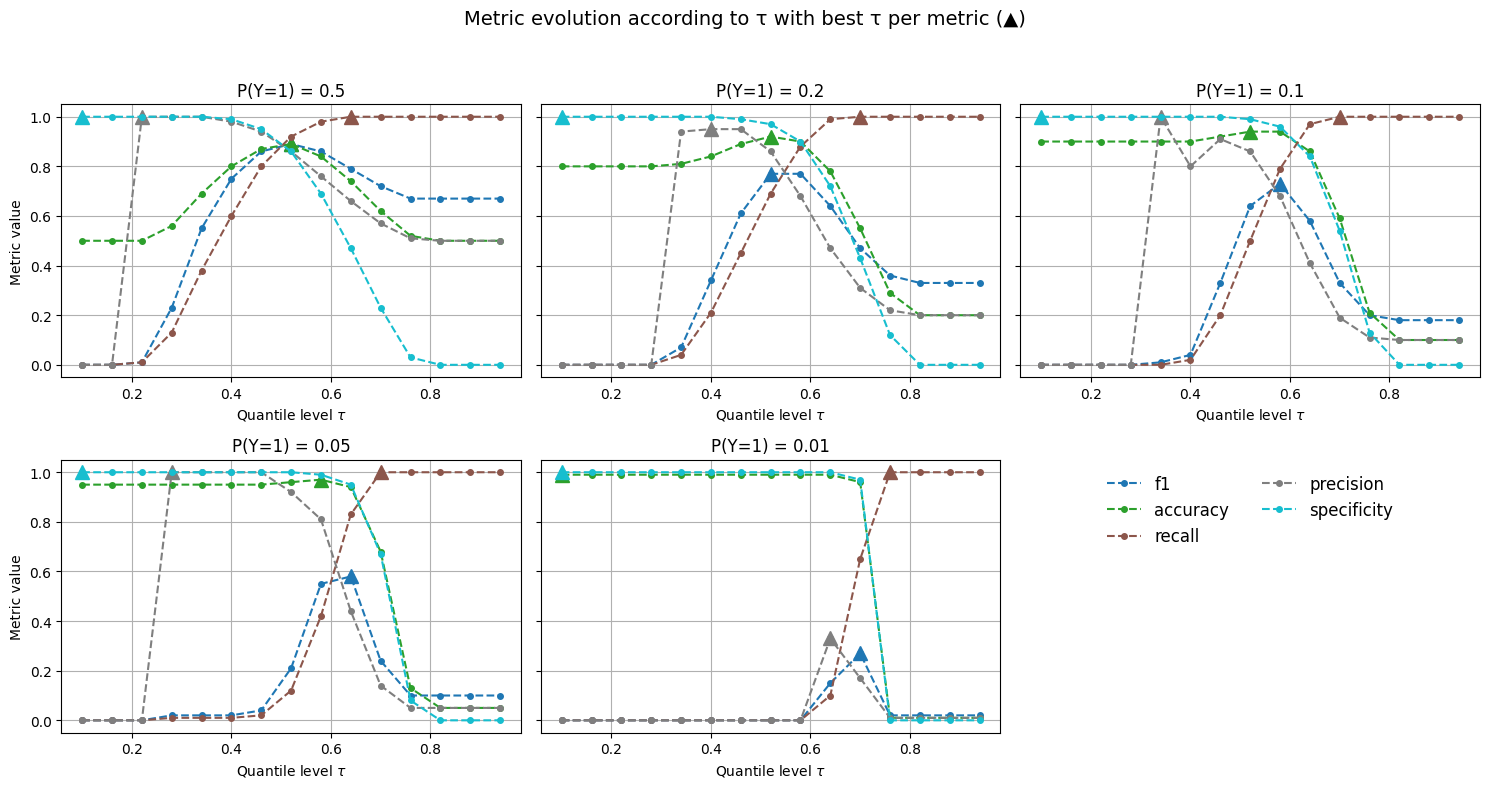

In [256]:
plot_metrics_vs_tau_for_imbalances(nb_cols=3)

In [ ]:
def plot_metrics_vs_tau(
        datasets = [(X_sheart, y_sheart), (X_churn, y_churn), (X_heart, y_heart), (X_fraud, y_fraud)],
        imbalances=[0.5, 0.2, 0.1, 0.05, 0.01], 
        tau_range=np.linspace(0.1, 1, 15, endpoint=False),
        nb_cols=2, 
        cost_10=10, cost_01=100, cost_11=10, cost_00=0
    ):
    """
    For each imbalance level in `imbalances`, plot metric curves as a function of τ (with denser sampling after 0.5),
    and highlight the τ that minimizes cost.
    """
    metrics_names = [
        "f1",  "accuracy", "balanced_accuracy", 
        "recall", "precision", "specificity"
    ]
    n = len(datasets)

    # Prepare subplots
    total_plots = n + 1 # one subplot for legend
    n_col = min(nb_cols, total_plots)
    n_row = total_plots//n_col + (total_plots%n_col > 0)

    fig, axes = plt.subplots(n_row, n_col, figsize=(15, 4*n_row), sharey=True)
    axes = axes.flatten()

    colors = plt.cm.get_cmap('tab10', len(metrics_names))

    for id, data in enumerate(datasets):

        print(f'Dataset {id}/{n}')
        X, y = data
        X_train, X_test, y_train, y_test = cross_val_set(X, y)

        metric_curves = {m: [] for m in metrics_names}

        for tau in tau_range:

            #print('Tau value: ', tau)

            # Fit model
            model = SQBC(tau=tau)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Retrieve metrics 
            metrics = evaluate(y_test, y_pred, cost_10, cost_01, cost_11, cost_00, plot=False)
            for m in metrics_names:
                metric_curves[m].append(metrics[m])

        # Plot metrics
        ax = axes[id]
        for i, m in enumerate(metrics_names):
            values = metric_curves[m]
            ax.plot(tau_range, values, linestyle='--', marker='o', markersize=4, color=colors(i), label=m)
            # Higlight best tau
            best_idx = np.argmin(values) if m=='cost' else np.argmax(values)
            best_tau = tau_range[best_idx]
            ax.plot(best_tau, values[best_idx], marker='^', markersize=10, color=colors(i))

        ax.set_xlabel(r"Quantile level $\tau$")
        if id % n_col == 0:
            ax.set_ylabel("Metric value")
        ax.grid(True)

    # Subplot for legend 
    legend_ax = axes[id+1]
    legend_ax.axis('off') 
    handles, labels = axes[0].get_legend_handles_labels()
    legend_ax.legend(handles, labels, loc='upper center', fontsize=12, ncol=2, frameon=False)

    # Delete empty plots
    for j in range(n+1, n_row * n_col):
        fig.delaxes(axes[j])

    plt.suptitle("Metric evolution according to τ with best τ per metric (▲)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Dataset 0/4
Dataset 1/4
Dataset 2/4
Dataset 3/4


NameError: name 'n_imbalances' is not defined

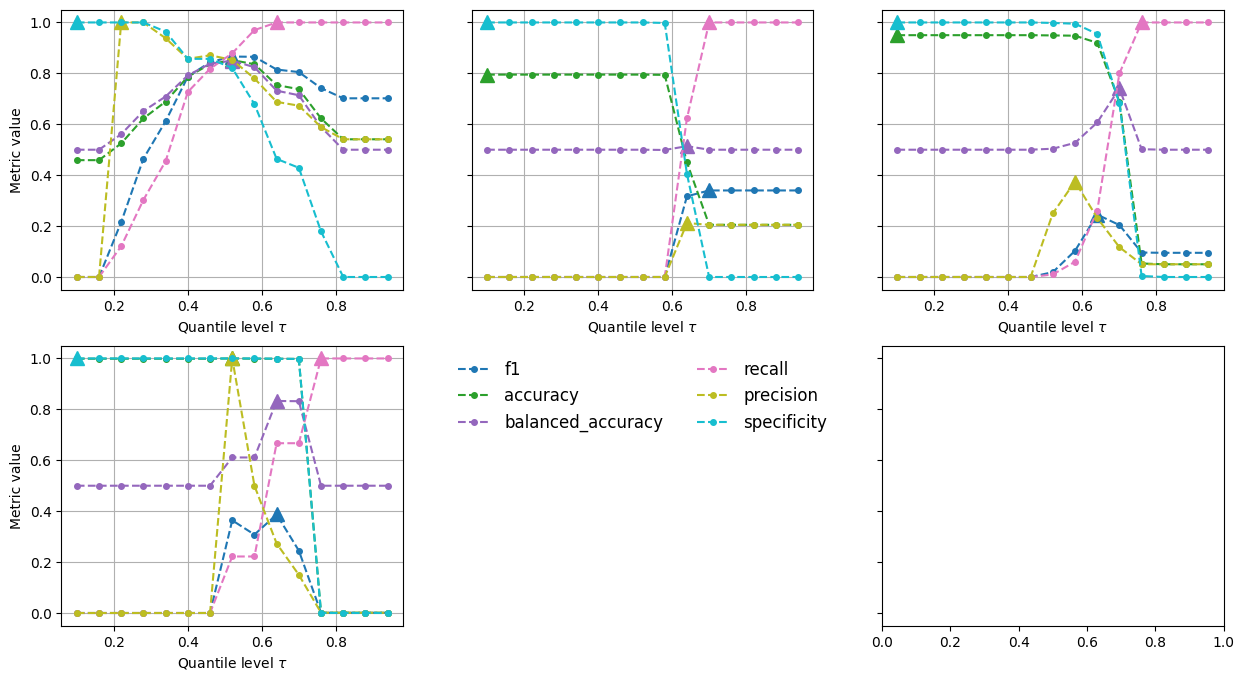

In [195]:
plot_metrics_vs_tau(nb_cols=3)

## Standard SQBC

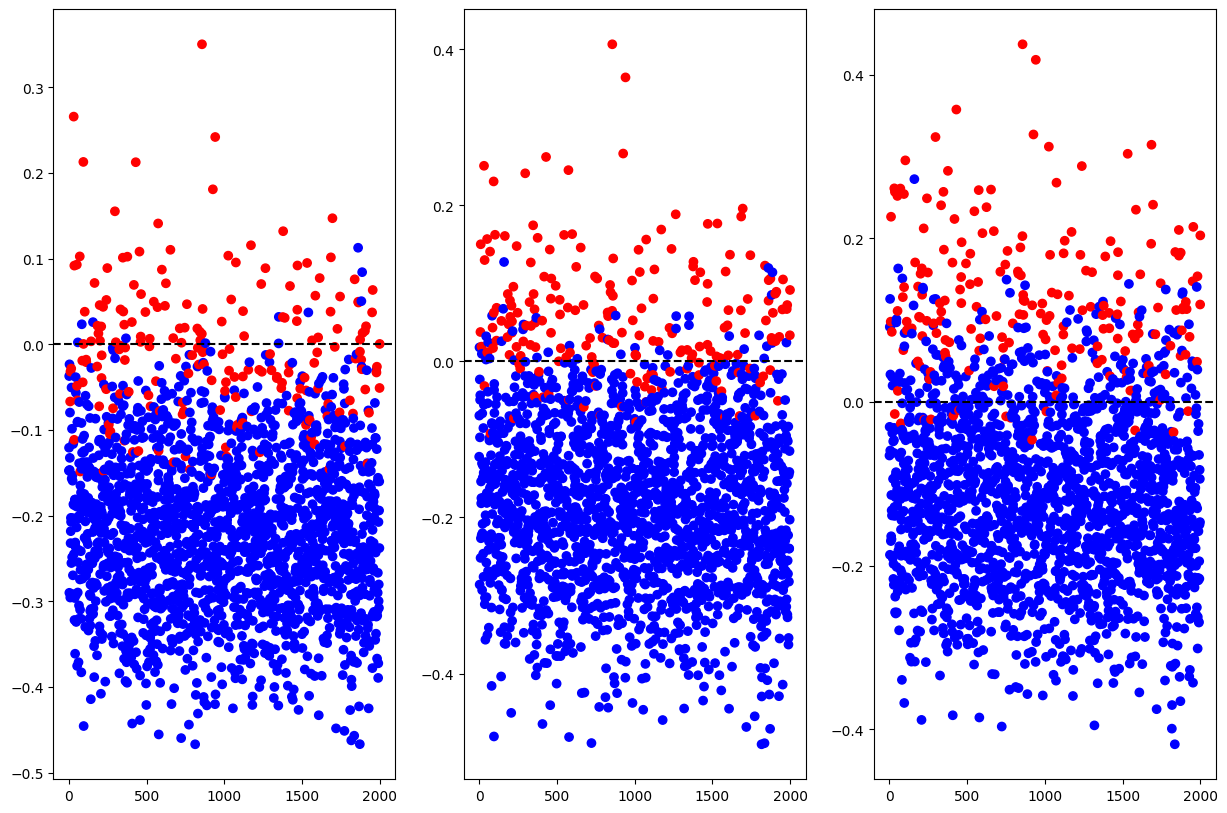

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 10), sharey=True)

for i, tau in enumerate([0.5, 0.65, 0.85]): 
 
    model_sqbc = NewSQBC(tau=tau)
    model_sqbc.fit(X_train_01, y_train_01)
    y_pred_sqbc = model_sqbc.predict_quantile(X_test_01)

    axs[i].scatter(range(len(y_pred_sqbc)), y_pred_sqbc, c=y_test_01, cmap='bwr')  
    axs[i].axhline(color='black', linestyle='--')

In [282]:
def optimize_threshold_sqbc(
    model, X_train, y_train, X_test, y_test, opt_metric="f1", 
    n_splits=3, verbose=True, method=None
    ):
    """
    Optimisation du seuil pour SQBC via cross-validation.
    """
    folds = cross_val_set(X_train, y_train, mode="kfold", n_splits=n_splits)
    
    metrics = {
        "f1": f1_score, "accuracy": accuracy_score, 
        "balanced_accuracy": balanced_accuracy_score, "recall":recall_score, 
        "precision": precision_score, "specificity": specificity_score
    }
    metric_fn = metrics[opt_metric]

    thresholds = []
    scores = []
    
    for fold_id, (X_train_val, X_val, y_train_val, y_val) in enumerate(folds):

        if verbose==True:
            print(f"Fold {fold_id+1}/{n_splits}")

        if method==1:
            model.fit1(X_train_val, y_train_val)
        elif method==2: 
            model.fit2(X_train_val, y_train_val)
        else:
            model.fit(X_train_val, y_train_val)

        y_prob = model.predict_quantile(X_val)
        
        # Search best threshold
        ts = np.concatenate((np.array([0]), np.linspace(min(y_prob), max(y_prob), 100)))
        fold_scores = [metric_fn(y_val, (y_prob >= t).astype(int)) for t in ts]
        
        best_idx = np.argmax(fold_scores)
        thresholds.append(ts[best_idx])
        scores.append(fold_scores[best_idx])
    
    best_threshold = np.median(thresholds)
    model.t = best_threshold
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_quantile(X_test)
    metrics = evaluate(y_test,y_pred.astype(int), y_prob, plot=False)

    return metrics, best_threshold

In [283]:
def train_eval_sqbc(
        X_train, y_train, X_test, y_test, 
        tau=0.5, alpha=0.5, h=0.1, t=0, new=False,
        opt_metric="f1", opt_thresh=False, verbose=True
    ):
  
    if new==True: 
        model= NewSQBC(tau=tau, alpha=alpha, h=h, t=t)

    else:
        model = SQBC(tau=tau, alpha=alpha, h=h, t=t)

    if opt_thresh==True:
        metrics, threshold = optimize_threshold_sqbc(
            model, X_train, y_train, X_test, y_test, opt_metric=opt_metric, verbose=verbose
        )
        metrics["Threshold"] = round(threshold, 2)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_quantile(X_test)
        metrics = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics["Threshold"] = 0.0

    metrics["Level_tau"] = tau

    return metrics 

## Hyperparameter tuning: grid search of $\tau$

In [292]:
def grid_search_tau_interpolated(X_train, y_train, X_test, y_test,
                                tau_range=np.linspace(0.4, 0.99, 11),
                                cost_10=10, cost_01=100, cost_11=10, cost_00=0,
                                n_splits=3, resolution=200, interpolation=True,
                                n_estimators=100, alpha=0.5, 
                                eta=0.1, h=0.1, t=0, 
                                random_state=0, base_learner="tree",
                                model_type="SQBC",
                                verbose=True, opt_metric="f1"):
    """
    Grid search over tau (with optional interpolation) to find the tau that optimizes opt_metric.
    """
    metrics_names = [
        "f1", "accuracy", "roc_auc", "pr_auc", 
        "recall", "precision", "specificity",
    ]
    if opt_metric not in metrics_names:
            raise ValueError("Invalid metric name")

    metric_curves = {m: np.zeros(len(tau_range)) for m in metrics_names}

    folds = cross_val_set(X_train, y_train, mode='kfold', n_splits=n_splits)
    for fold_id, (X_train_val, X_val, y_train_val, y_val) in enumerate(folds):
        
        if verbose==True: 
            print(f"Fold {fold_id + 1}/{n_splits}")

        for i, tau in enumerate(tau_range):
        
            # Create model
            if model_type=="SQBC":
                model = SQBC(
                            n_estimators=n_estimators, alpha=alpha, 
                            tau=tau, eta=eta, h=h, t=t, 
                            random_state=random_state, base_learner=base_learner
                        )
                # Fit and predict
                model.fit(X_train_val, y_train_val)
                y_pred = model.predict(X_val)
                y_prob = model.predict_quantile(X_val)

            elif model_type=="XGB":
                model = XGBSQBC(tau=tau, alpha=alpha, h=h)
                # Fit and predict
                model.fit(X_train_val, y_train_val)
                y_pred = model.predict(X_val)
                y_prob = model.predict_proba(X_val)[:,1]

            # Retrieve metrics
            metrics = evaluate(y_val, y_pred, y_prob, plot=False)
            for m in metric_curves:
                metric_curves[m][i] += metrics[m] / n_splits  # average over folds
        

    if interpolation==True: 
        interpolator = interp1d(tau_range, metric_curves[opt_metric])
        fine_taus = np.linspace(tau_range.min(), tau_range.max(), resolution)
        fine_metrics = interpolator(fine_taus)

        best_idx = np.argmin(fine_metrics) if opt_metric=='cost' else np.argmax(fine_metrics)
        best_tau = fine_taus[best_idx]

        
    else: 
        best_idx = np.argmin(metric_curves[opt_metric]) if opt_metric=='cost' else np.argmax(metric_curves[opt_metric])
        best_tau = tau_range[best_idx]
    

    # Model with best tau
    if model_type=="SQBC":
        model = SQBC(
                    n_estimators=n_estimators, alpha=alpha, 
                    tau=best_tau, eta=eta, h=h, t=t, 
                    random_state=random_state, base_learner=base_learner
                )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_quantile(X_test)
        metrics_at_best = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics_at_best["Threshold"] = model.t


    elif model_type=="XGB":
        model = XGBSQBC(tau=best_tau, alpha=alpha, h=h)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        metrics_at_best = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics_at_best["Threshold"] = 0.5
         
    else:
        raise ValueError("model should be 'SQBC' or 'XGB'")
    
    metrics_at_best["Level_tau"] = round(best_tau, 2)

    return metrics_at_best

In [ ]:
grid_sqbc_metrics_05 = grid_search_tau_interpolated(X_train_05, y_train_05, X_test_05, y_test_05)
grid_sqbc_metrics_01 = grid_search_tau_interpolated(X_train_01, y_train_01, X_test_01, y_test_01)
grid_sqbc_metrics_005 = grid_search_tau_interpolated(X_train_005, y_train_005, X_test_005, y_test_005)
grid_sqbc_metrics_002 = grid_search_tau_interpolated(X_train_002, y_train_002, X_test_002, y_test_002)
grid_sqbc_metrics_001 = grid_search_tau_interpolated(X_train_001, y_train_001, X_test_001, y_test_001)

grid_sqbc_metrics_sheart =  grid_search_tau_interpolated(X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart)
grid_sqbc_metrics_churn =  grid_search_tau_interpolated(X_train_churn, y_train_churn, X_test_churn, y_test_churn)
grid_sqbc_metrics_heart =  grid_search_tau_interpolated(X_train_heart, y_train_heart, X_test_heart, y_test_heart)
grid_sqbc_metrics_fraud =  grid_search_tau_interpolated(X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud)

resultats = {
    "grid_sqbc_metrics_05": grid_sqbc_metrics_05,
    "grid_sqbc_metrics_01": grid_sqbc_metrics_01,
    "grid_sqbc_metrics_005": grid_sqbc_metrics_005,
    "grid_sqbc_metrics_002": grid_sqbc_metrics_002,
    "grid_sqbc_metrics_001": grid_sqbc_metrics_001,
    "grid_sqbc_metrics_sheart": grid_sqbc_metrics_sheart,
    "grid_sqbc_metrics_churn": grid_sqbc_metrics_churn,
    "grid_sqbc_metrics_heart": grid_sqbc_metrics_heart,
    "grid_sqbc_metrics_fraud": grid_sqbc_metrics_fraud
}

with open("resultats_grid_sqbc.pkl", "wb") as f:
    pickle.dump(resultats, f)

Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.939, 'Accuracy': 0.938, 'Balanced Accuracy': 0.938, 'Recall': 0.948, 'Precision': 0.929, 'Specificity': 0.928, 'Cost': 0.14, 'Level_tau': 0.5566331658291458}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.784, 'Accuracy': 0.954, 'Balanced Accuracy': 0.901, 'Recall': 0.835, 'Precision': 0.739, 'Specificity': 0.967, 'Cost': 0.146, 'Level_tau': 0.6600502512562815}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.559, 'Accuracy': 0.961, 'Balanced Accuracy': 0.742, 'Recall': 0.5, 'Precision': 0.633, 'Specificity': 0.985, 'Cost': 0.2, 'Level_tau': 0.6649748743718593}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.342, 'Accuracy': 0.975, 'Balanced Accuracy': 0.657, 'Recall': 0.325, 'Precision': 0.361, 'Specificity': 0.988, 'Cost': 0.13, 'Level_tau': 0.773316582914573}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.214, 'Accuracy': 0.978, 'Balanced Accuracy': 0.642, 'Recall': 0.3, 'Precision': 0.167, 'Specificity': 0.985, 'Cost': 0.081, 'Level_tau': 0.8816582914572865}
Fold

## XGBoost with SQBC loss

In [137]:
# Custom loss
def sqbc_like_loss(tau=0.5, alpha=0.5, h=0.1, eps=1e-6):
    """
    SQBC-inspired loss function for XGBoost.
    """

    def sqbc_obj(y_pred, dtrain):

        y_true = dtrain.get_label()
        f = y_pred  # raw score / logit

        Kf = norm.cdf(f/h) 
        K_prime_f = norm.pdf(f/h) / h
        K_sec_f = -f/h**3 * norm.pdf(f/h)
        exp_term = np.exp((y_true - Kf)/alpha)

        grad = -K_prime_f * (tau - 1 / (1 + exp_term))
        #hess = np.ones_like(grad) * 0.1
        hess = -K_sec_f * (tau - 1 / (1 + exp_term)) + K_prime_f**2/alpha * exp_term/(1+exp_term)**2 
        hess_clipped = np.maximum(hess, eps)
        
        return grad, hess_clipped

    return sqbc_obj

In [138]:
class XGBSQBC(BaseEstimator):
    """XGBoost classifier with SQBC-like custom loss."""

    _estimator_type = "classifier"

    def __init__(self, tau=0.5, alpha=0.5, h=0.1,
                 max_depth=3, eta=0.1, n_estimators=100, random_state=0):
        self.tau = tau
        self.alpha = alpha
        self.h = h
        self.max_depth = max_depth
        self.eta = eta
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        
        dtrain = xgb.DMatrix(X, label=y)
        params = {
            "objective": 'binary:logistic',
            "max_depth": self.max_depth,
            "eta": self.eta,
            "verbosity": 0,
            "seed": self.random_state
        }
        self.bst_ = xgb.train(
            params, dtrain, num_boost_round=self.n_estimators,
            obj=sqbc_like_loss(self.tau, self.alpha, self.h)
        )
        return self

    def predict_proba(self, X):
        dtest = xgb.DMatrix(X)
        y_proba = self.bst_.predict(dtest)
        return np.column_stack((1 - y_proba, y_proba))

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)


In [139]:
def train_eval_xgb_sqbc(
        X_train, y_train, X_test, y_test, 
        tau=0.5, alpha=0.5, h=0.1, 
        opt_metric="f1", opt_thresh=False
    ):
  
    model = XGBSQBC(tau=tau, alpha=alpha, h=h)

    metrics = train_eval_sota_model(
        X_train, y_train, X_test, y_test, model, 
        opt_metric=opt_metric, opt_thresh=opt_thresh
    ) 

    metrics["Level_tau"] = tau

    return metrics 

##### **Fixed $\tau$**

In [367]:
xgb_sqbc_metrics_05 = train_eval_xgb_sqbc(X_train_05, y_train_05, X_test_05, y_test_05)
xgb_sqbc_metrics_01 = train_eval_xgb_sqbc(X_train_01, y_train_01, X_test_01, y_test_01)
xgb_sqbc_metrics_005 = train_eval_xgb_sqbc(X_train_005, y_train_005, X_test_005, y_test_005)
xgb_sqbc_metrics_002 = train_eval_xgb_sqbc(X_train_002, y_train_002, X_test_002, y_test_002)
xgb_sqbc_metrics_001 = train_eval_xgb_sqbc(X_train_001, y_train_001, X_test_001, y_test_001)

xgb_sqbc_metrics_sheart =  train_eval_xgb_sqbc(X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart)
xgb_sqbc_metrics_churn =  train_eval_xgb_sqbc(X_train_churn, y_train_churn, X_test_churn, y_test_churn)
xgb_sqbc_metrics_heart =  train_eval_xgb_sqbc(X_train_heart, y_train_heart, X_test_heart, y_test_heart)
xgb_sqbc_metrics_fraud =  train_eval_xgb_sqbc(X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud)

resultats = {
    "xgb_sqbc_metrics_05": xgb_sqbc_metrics_05,
    "xgb_sqbc_metrics_01": xgb_sqbc_metrics_01,
    "xgb_sqbc_metrics_005": xgb_sqbc_metrics_005,
    "xgb_sqbc_metrics_002": xgb_sqbc_metrics_002,
    "xgb_sqbc_metrics_001": xgb_sqbc_metrics_001,
    "xgb_sqbc_metrics_sheart":xgb_sqbc_metrics_sheart,
    "xgb_sqbc_metrics_churn": xgb_sqbc_metrics_churn,
    "xgb_sqbc_metrics_heart": xgb_sqbc_metrics_heart,
    "xgb_sqbc_metrics_fraud": xgb_sqbc_metrics_fraud
}

with open("resultats_xgb_sqbc.pkl", "wb") as f:
    pickle.dump(resultats, f)

{'f1': 0.911, 'roc_auc': 0.912, 'accuracy': 0.911, 'balanced_accuracy': 0.912, 'recall': 0.905, 'precision': 0.917, 'specificity': 0.918, 'cost': 0.176, 'Threshold': 0.5, 'Level_tau': 0.5}
{'f1': 0.756, 'roc_auc': 0.821, 'accuracy': 0.958, 'balanced_accuracy': 0.821, 'recall': 0.65, 'precision': 0.903, 'specificity': 0.992, 'cost': 0.222, 'Threshold': 0.5, 'Level_tau': 0.5}
{'f1': 0.568, 'roc_auc': 0.708, 'accuracy': 0.968, 'balanced_accuracy': 0.708, 'recall': 0.42, 'precision': 0.875, 'specificity': 0.997, 'cost': 0.217, 'Threshold': 0.5, 'Level_tau': 0.5}
{'f1': 0.377, 'roc_auc': 0.624, 'accuracy': 0.984, 'balanced_accuracy': 0.624, 'recall': 0.25, 'precision': 0.769, 'specificity': 0.998, 'cost': 0.133, 'Threshold': 0.5, 'Level_tau': 0.5}
{'f1': 0.167, 'roc_auc': 0.549, 'accuracy': 0.99, 'balanced_accuracy': 0.549, 'recall': 0.1, 'precision': 0.5, 'specificity': 0.999, 'cost': 0.084, 'Threshold': 0.5, 'Level_tau': 0.5}
{'f1': 0.765, 'roc_auc': 0.733, 'accuracy': 0.738, 'balanced_ac

##### **Grid search $\tau$**

In [187]:
grid_xgb_sqbc_metrics_05, _ = grid_search_tau_interpolated(X_train_05, y_train_05, X_test_05, y_test_05, model_type="XGB")
grid_xgb_sqbc_metrics_01, _ = grid_search_tau_interpolated(X_train_01, y_train_01, X_test_01, y_test_01, model_type="XGB")
grid_xgb_sqbc_metrics_005, _ = grid_search_tau_interpolated(X_train_005, y_train_005, X_test_005, y_test_005, model_type="XGB")
grid_xgb_sqbc_metrics_002, _ = grid_search_tau_interpolated(X_train_002, y_train_002, X_test_002, y_test_002, model_type="XGB")
grid_xgb_sqbc_metrics_001, _ = grid_search_tau_interpolated(X_train_001, y_train_001, X_test_001, y_test_001, model_type="XGB")

grid_xgb_sqbc_metrics_sheart, _ =  grid_search_tau_interpolated(X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart, model_type="XGB")
grid_xgb_sqbc_metrics_churn, _ =  grid_search_tau_interpolated(X_train_churn, y_train_churn, X_test_churn, y_test_churn, model_type="XGB")
grid_xgb_sqbc_metrics_heart, _ =  grid_search_tau_interpolated(X_train_heart, y_train_heart, X_test_heart, y_test_heart, model_type="XGB")
grid_xgb_sqbc_metrics_fraud, _ =  grid_search_tau_interpolated(X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud, model_type="XGB")

resultats = {
    "grid_xgb_sqbc_metrics_05": grid_xgb_sqbc_metrics_05,
    "grid_xgb_sqbc_metrics_01": grid_xgb_sqbc_metrics_01,
    "grid_xgb_sqbc_metrics_005": grid_xgb_sqbc_metrics_005,
    "grid_xgb_sqbc_metrics_002": grid_xgb_sqbc_metrics_002,
    "grid_xgb_sqbc_metrics_001": grid_xgb_sqbc_metrics_001,
    "grid_xgb_sqbc_metrics_sheart":grid_xgb_sqbc_metrics_sheart,
    "grid_xgb_sqbc_metrics_churn": grid_xgb_sqbc_metrics_churn,
    "grid_xgb_sqbc_metrics_heart": grid_xgb_sqbc_metrics_heart,
    "grid_xgb_sqbc_metrics_fraud": grid_xgb_sqbc_metrics_fraud
}

with open("resultats_grid_xgb_sqbc.pkl", "wb") as f:
    pickle.dump(resultats, f)

Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.892, 'Accuracy': 0.888, 'Balanced Accuracy': 0.888, 'Recall': 0.929, 'Precision': 0.859, 'Specificity': 0.847, 'Cost': 0.163, 'Threshold': 0.573, 'Level_tau': 0.44829145728643216}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.745, 'Accuracy': 0.941, 'Balanced Accuracy': 0.909, 'Recall': 0.87, 'Precision': 0.652, 'Specificity': 0.948, 'Cost': 0.139, 'Threshold': 0.553, 'Level_tau': 0.6600502512562815}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.796, 'Accuracy': 0.981, 'Balanced Accuracy': 0.876, 'Recall': 0.76, 'Precision': 0.835, 'Specificity': 0.992, 'Cost': 0.114, 'Threshold': 0.557, 'Level_tau': 0.6649748743718593}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.712, 'Accuracy': 0.99, 'Balanced Accuracy': 0.823, 'Recall': 0.65, 'Precision': 0.788, 'Specificity': 0.996, 'Cost': 0.073, 'Threshold': 0.558, 'Level_tau': 0.773316582914573}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.481, 'Accuracy': 0.986, 'Balanced Accuracy': 0.82, 'Recall': 0.65, 'Precision'

## Learning $\tau$ in SQBC

In [ ]:
class GradSQBC(SQBC):

    def __init__(self, n_estimators=100, alpha=0.5, 
                 theta=0, eta=0.1, h=0.1, t=0, 
                 random_state=0, base_learner="tree",
                 lr_theta = 0.1):
        if base_learner not in ["tree", "OLS"]:
            raise ValueError("base_learner must be 'tree' or 'OLS'")
        self.n_estimators = n_estimators
        self.alpha = alpha
        self.theta = theta
        self.tau = 1 / (1 + np.exp(-self.theta))
        self.eta = eta
        self.h = h
        self.t = t
        self.random_state = random_state
        self.base_learner = base_learner
        self.lr_theta = lr_theta


    def fit1(self, X, y, theta=0, verbose=False, base_learner="tree"):
        f = np.zeros(len(y))
        self.base_learner = base_learner
        self.models = []
        self.theta = theta
        self.tau = 1 / (1 + np.exp(-self.theta))
        self.loss_history = []

        for m in range(self.n_estimators):

            Kf = norm.cdf(f/self.h)
            K_prime_f = norm.pdf(f/self.h) / self.h
            U = -K_prime_f * (1/(1 + np.exp((y - Kf)/self.alpha)) - self.tau)
            
            if self.base_learner == "tree":
                model = DecisionTreeRegressor(max_depth=1, random_state=self.random_state)
            elif self.base_learner == "OLS":
                model = LinearRegression()

            model.fit(X, U)
            self.models.append(model)
            f += self.eta * model.predict(X)

            grad_theta = np.mean(y - Kf) * self.tau * (1 - self.tau)
            self.theta -= self.lr_theta * grad_theta
            self.tau = 1 / (1 + np.exp(-self.theta))


            # Keep loss
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)
            if (m % 10 == 0) and verbose:
                print(f"Iter {m}, loss = {loss:.4f},  theta = {self.theta:.4f}, tau = {self.tau:.4f}")

    def fit2(self, X, y, theta=0, verbose=False): 
        f = np.zeros(len(y))
        self.base_learner = "OLS"
        self.models = []
        self.theta = theta
        #self.theta = theta
        self.tau = 1 / (1 + np.exp(-self.theta))
        self.loss_history = []

        for m in range(self.n_estimators):

            Kf = norm.cdf(f/self.h)
            K_prime_f = norm.pdf(f/self.h) / self.h
            U = -K_prime_f * (1/(1 + np.exp((y - Kf)/self.alpha)) - self.tau)
            
            model = LinearRegression()
            model.fit(X, U)
            self.models.append(model)
            f += self.eta*model.predict(X)

            H = X @ np.linalg.inv(X.T @ X) @ X.T
            dU_dtau = K_prime_f # depends on f(m-1)
            df_dtau = self.eta * (H @ dU_dtau)
            dl_df = -U
            dl_dtau = (y - norm.cdf(f / self.h)) # depends on f(m)
            dtau_dtheta =  self.tau * (1 - self.tau)

            # Complete gradient
            dl_dtheta =  np.mean(dl_df * df_dtau + dl_dtau) * dtau_dtheta
            self.theta -= self.lr_theta * dl_dtheta
            self.tau = 1 / (1 + np.exp(-self.theta))

            # Keep loss
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)
            if (m % 10 == 0) and verbose: 
                print(f"Iter {m}, loss = {loss:.4f}, theta = {self.theta:.4f}, tau = {self.tau:.4f}")
    
    
    def get_params(self, deep=True):
        return {
            "n_estimators": self.n_estimators,
            "alpha": self.alpha,
            "theta": self.theta,
            "eta": self.eta,
            "h": self.h,
            "t": self.t,
            "base_learner": self.base_learner
        }

In [295]:
def train_eval_grad_sqbc(
        X_train, y_train, X_test, y_test, 
        theta=0, alpha=0.5, h=0.1, t=0, lr_theta=0.1,
        opt_metric="f1", opt_thresh=False, method=1,
        verbose=False
    ):
  
    if method not in [1, 2]: 
        raise ValueError("Method must be equal to 1 or 2")

    model = GradSQBC(
        theta=theta, alpha=alpha, 
        h=h, t=t, lr_theta=lr_theta
    )
    
    if opt_thresh==True:
        metrics, threshold = optimize_threshold_sqbc(
            model, X_train, y_train, X_test, y_test, 
            opt_metric=opt_metric, method=method, 
            verbose=verbose
        )
        metrics["Threshold"] = round(threshold, 2)

    else : 
        if method==1: 
            model.fit1(X_train, y_train)
        elif method==2: 
            model.fit2(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_quantile(X_test)
        metrics = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics["Threshold"] = 0.0

    metrics["Level_tau"] = round(model.tau, 2)

    return metrics 

Iter 0, loss = 0.3535,  theta = 0.3110, tau = 0.5771
Iter 10, loss = 0.3488,  theta = 0.3547, tau = 0.5878


Iter 20, loss = 0.3468,  theta = 0.3983, tau = 0.5983
Iter 30, loss = 0.3443,  theta = 0.4470, tau = 0.6099
Iter 40, loss = 0.3412,  theta = 0.5012, tau = 0.6228
Iter 50, loss = 0.3375,  theta = 0.5616, tau = 0.6368
Iter 60, loss = 0.3329,  theta = 0.6285, tau = 0.6522
Iter 70, loss = 0.3273,  theta = 0.7021, tau = 0.6687
Iter 80, loss = 0.3207,  theta = 0.7824, tau = 0.6862
Iter 90, loss = 0.3130,  theta = 0.8694, tau = 0.7046


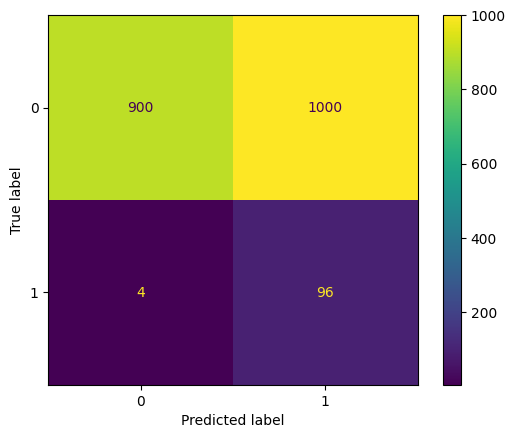

{'f1': 0.16, 'accuracy': 0.5, 'balanced_accuracy': 0.72, 'recall': 0.96, 'precision': 0.09, 'specificity': 0.47}


{'f1': 0.16,
 'accuracy': 0.5,
 'balanced_accuracy': 0.72,
 'recall': 0.96,
 'precision': 0.09,
 'specificity': 0.47}

In [233]:
model = GradSQBC()
model.fit1(X_train_heart, y_train_heart, theta=0.3, verbose=True)
pred =  model.predict(X_test_heart)
evaluate(y_test_heart, pred)

In [ ]:
p = 0.2
k = 0.05
model = GradSQBC(theta=k*np.log((1-p) / (p)), lr_theta=0.5)
model.fit_accumulate(X_train_churn, y_train_churn, verbose=True)
model.plot_loss()
y_pred = model.predict(X_test_churn)
evaluate(y_test_churn, y_pred)

In [ ]:
x = np.linspace(0.01, 0.99, 100)  # éviter 0 et 1 pour éviter log(0)
ks = [0.05, 0.1, 0.5, 1]  # différentes valeurs de k

for k in ks:
    y = k * np.log((1 - x) / x)
    plt.plot(x, y, label=f'k={k}')

plt.xlabel('p')
plt.ylabel('theta')
plt.title('Courbes pour différentes valeurs de k')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
grad_sqbc_metrics_05 = train_eval_grad_sqbc(X_train_05, y_train_05, X_test_05, y_test_05)
grad_sqbc_metrics_01 = train_eval_grad_sqbc(X_train_01, y_train_01, X_test_01, y_test_01)
grad_sqbc_metrics_005 = train_eval_grad_sqbc(X_train_005, y_train_005, X_test_005, y_test_005)
grad_sqbc_metrics_002 = train_eval_grad_sqbc(X_train_002, y_train_002, X_test_002, y_test_002)
grad_sqbc_metrics_001 = train_eval_grad_sqbc(X_train_001, y_train_001, X_test_001, y_test_001)

grad_sqbc_metrics_sheart =  train_eval_grad_sqbc(X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart)
grad_sqbc_metrics_churn =  train_eval_grad_sqbc(X_train_churn, y_train_churn, X_test_churn, y_test_churn)
grad_sqbc_metrics_heart =  train_eval_grad_sqbc(X_train_heart, y_train_heart, X_test_heart, y_test_heart)
grad_sqbc_metrics_fraud =  train_eval_grad_sqbc(X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud)

resultats = {
    "grad_sqbc_metrics_05": grad_sqbc_metrics_05,
    "grad_sqbc_metrics_01": grad_sqbc_metrics_01,
    "grad_sqbc_metrics_005": grad_sqbc_metrics_005,
    "grad_sqbc_metrics_002": grad_sqbc_metrics_002,
    "grad_sqbc_metrics_001": grad_sqbc_metrics_001,
    "grad_sqbc_metrics_sheart":grad_sqbc_metrics_sheart,
    "grad_sqbc_metrics_churn": grad_sqbc_metrics_churn,
    "grad_sqbc_metrics_heart": grad_sqbc_metrics_heart,
    "grad_sqbc_metrics_fraud": grad_sqbc_metrics_fraud
}

with open("resultats_grad_sqbc.pkl", "wb") as f:
    pickle.dump(resultats, f)

Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.959, 'Accuracy': 0.959, 'Balanced Accuracy': 0.959, 'Recall': 0.951, 'Precision': 0.966, 'Specificity': 0.967, 'Cost': 0.134, 'Threshold': 0.004, 'Level_tau': 0.5}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.835, 'Accuracy': 0.964, 'Balanced Accuracy': 0.946, 'Recall': 0.925, 'Precision': 0.761, 'Specificity': 0.968, 'Cost': 0.103, 'Threshold': 0.0, 'Level_tau': 0.549}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.821, 'Accuracy': 0.981, 'Balanced Accuracy': 0.928, 'Recall': 0.87, 'Precision': 0.777, 'Specificity': 0.987, 'Cost': 0.083, 'Threshold': -0.006, 'Level_tau': 0.555}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.519, 'Accuracy': 0.981, 'Balanced Accuracy': 0.757, 'Recall': 0.525, 'Precision': 0.512, 'Specificity': 0.99, 'Cost': 0.098, 'Threshold': -0.019, 'Level_tau': 0.567}
Fold 1/3
Fold 2/3
Fold 3/3
{'F1-score': 0.453, 'Accuracy': 0.986, 'Balanced Accuracy': 0.795, 'Recall': 0.6, 'Precision': 0.364, 'Specificity': 0.989, 'Cost': 0.052, 'Thres

## Combined results

In [245]:
model_names=["XGBoost", "LightGBM", "CatBoost", "Random_Forest", "Logistic_Regression",
            "SQBC_grid_search", "XGB_SQBC_loss", "XGB_SQBC_loss_grid_search", "Grad_SQBC"]

combine_results(soa_metrics_05+[grid_sqbc_metrics_05, xgb_sqbc_metrics_05, grid_xgb_sqbc_metrics_05, grad_sqbc_metrics_05],
                            model_names=model_names)
combine_results(soa_metrics_01+[grid_sqbc_metrics_01, xgb_sqbc_metrics_01, grid_xgb_sqbc_metrics_01, grad_sqbc_metrics_01],
                            model_names=model_names)
combine_results(soa_metrics_005+[grid_sqbc_metrics_005, xgb_sqbc_metrics_005,  grid_xgb_sqbc_metrics_005, grad_sqbc_metrics_005],
                            model_names=model_names)
combine_results(soa_metrics_002+[grid_sqbc_metrics_002, xgb_sqbc_metrics_002,  grid_xgb_sqbc_metrics_002, grad_sqbc_metrics_002],
                            model_names=model_names)
combine_results(soa_metrics_001+[grid_sqbc_metrics_001, xgb_sqbc_metrics_001,  grid_xgb_sqbc_metrics_001, grad_sqbc_metrics_001],
                            model_names=model_names)

combine_results(soa_metrics_sheart+[grid_sqbc_metrics_sheart, xgb_sqbc_metrics_sheart, grid_xgb_sqbc_metrics_sheart, grad_sqbc_metrics_sheart],
                            model_names=model_names)
combine_results(soa_metrics_churn+[grid_sqbc_metrics_churn, xgb_sqbc_metrics_churn, grid_xgb_sqbc_metrics_churn, grad_sqbc_metrics_churn],
                            model_names=model_names)
combine_results(soa_metrics_heart+[grid_sqbc_metrics_heart, xgb_sqbc_metrics_heart,  grid_xgb_sqbc_metrics_heart, grad_sqbc_metrics_heart],
                            model_names=model_names)
combine_results(soa_metrics_fraud+[grid_sqbc_metrics_fraud, xgb_sqbc_metrics_fraud,  grid_xgb_sqbc_metrics_fraud, grad_sqbc_metrics_fraud],
                            model_names=model_names)

,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Logistic_Regression,0.997,0.998,0.998,0.997,0.998,0.998,0.094,0.505,nan
CatBoost,0.973,0.973,0.973,0.977,0.969,0.969,0.113,0.475,nan
XGBoost,0.964,0.965,0.964,0.956,0.973,0.973,0.129,0.576,nan
XGB_SQBC_loss,0.963,0.963,0.962,0.973,0.953,0.952,0.117,0.497,0.500
Grad_SQBC,0.959,0.959,0.959,0.951,0.966,0.967,0.134,0.004,0.500
LightGBM,0.956,0.957,0.956,0.942,0.970,0.971,0.141,0.566,nan
Random_Forest,0.947,0.948,0.948,0.940,0.954,0.955,0.144,0.505,nan
SQBC_grid_search,0.939,0.938,0.938,0.948,0.929,0.928,0.140,nan,0.557
XGB_SQBC_loss_grid_search,0.892,0.888,0.888,0.929,0.859,0.847,0.163,0.573,0.448


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Logistic_Regression,0.990,0.998,0.992,0.985,0.995,0.999,0.060,0.465,nan
CatBoost,0.922,0.985,0.956,0.920,0.925,0.992,0.094,0.394,nan
XGBoost,0.909,0.982,0.946,0.900,0.918,0.991,0.104,0.384,nan
LightGBM,0.894,0.979,0.946,0.905,0.883,0.987,0.104,0.374,nan
XGB_SQBC_loss,0.883,0.977,0.927,0.865,0.901,0.989,0.122,0.497,0.500
Grad_SQBC,0.835,0.964,0.946,0.925,0.761,0.968,0.103,0.000,0.549
Random_Forest,0.831,0.964,0.935,0.900,0.773,0.971,0.114,0.323,nan
SQBC_grid_search,0.784,0.954,0.901,0.835,0.739,0.967,0.146,nan,0.660
XGB_SQBC_loss_grid_search,0.745,0.941,0.909,0.870,0.652,0.948,0.139,0.553,0.660


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Logistic_Regression,0.990,0.999,0.995,0.990,0.990,0.999,0.038,0.444,nan
CatBoost,0.910,0.991,0.953,0.910,0.910,0.995,0.066,0.303,nan
XGBoost,0.886,0.989,0.942,0.890,0.881,0.994,0.073,0.253,nan
XGB_SQBC_loss,0.872,0.987,0.955,0.920,0.829,0.990,0.066,0.488,0.500
LightGBM,0.863,0.987,0.922,0.850,0.876,0.994,0.085,0.263,nan
Random_Forest,0.822,0.982,0.910,0.830,0.814,0.990,0.094,0.300,nan
Grad_SQBC,0.821,0.981,0.928,0.870,0.777,0.987,0.083,-0.006,0.555
XGB_SQBC_loss_grid_search,0.796,0.981,0.876,0.760,0.835,0.992,0.114,0.557,0.665
SQBC_grid_search,0.559,0.961,0.742,0.500,0.633,0.985,0.200,nan,0.665


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Logistic_Regression,0.951,0.998,0.987,0.975,0.929,0.998,0.022,0.404,nan
XGBoost,0.810,0.992,0.922,0.850,0.773,0.995,0.044,0.152,nan
XGB_SQBC_loss,0.785,0.992,0.885,0.775,0.795,0.996,0.055,0.490,0.500
LightGBM,0.769,0.990,0.933,0.875,0.686,0.992,0.043,0.040,nan
CatBoost,0.740,0.991,0.836,0.675,0.818,0.997,0.069,0.343,nan
Random_Forest,0.740,0.991,0.836,0.675,0.818,0.997,0.069,0.324,nan
XGB_SQBC_loss_grid_search,0.712,0.990,0.823,0.650,0.788,0.996,0.073,0.558,0.773
Grad_SQBC,0.519,0.981,0.757,0.525,0.512,0.990,0.098,-0.019,0.567
SQBC_grid_search,0.342,0.975,0.657,0.325,0.361,0.988,0.130,nan,0.773


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Logistic_Regression,0.826,0.996,0.973,0.950,0.731,0.996,0.017,0.374,nan
CatBoost,0.735,0.994,0.947,0.900,0.621,0.994,0.022,0.161,nan
LightGBM,0.723,0.994,0.922,0.850,0.630,0.995,0.026,0.020,nan
XGBoost,0.696,0.993,0.897,0.800,0.615,0.995,0.030,0.111,nan
XGB_SQBC_loss,0.625,0.991,0.872,0.750,0.536,0.993,0.036,0.483,0.500
Random_Forest,0.542,0.989,0.821,0.650,0.464,0.992,0.045,0.182,nan
XGB_SQBC_loss_grid_search,0.481,0.986,0.820,0.650,0.382,0.989,0.048,0.534,0.882
Grad_SQBC,0.453,0.986,0.795,0.600,0.364,0.989,0.052,-0.045,0.584
SQBC_grid_search,0.214,0.978,0.642,0.300,0.167,0.985,0.081,nan,0.882


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
CatBoost,0.879,0.869,0.868,0.879,0.879,0.857,0.204,0.495,nan
XGB_SQBC_loss_grid_search,0.865,0.836,0.824,0.970,0.780,0.679,0.142,0.542,0.335
Logistic_Regression,0.861,0.836,0.827,0.939,0.795,0.714,0.165,0.365,nan
LightGBM,0.857,0.836,0.830,0.909,0.811,0.750,0.187,0.414,nan
SQBC_grid_search,0.849,0.820,0.809,0.939,0.775,0.679,0.168,nan,0.768
Random_Forest,0.848,0.836,0.835,0.848,0.848,0.821,0.232,0.500,nan
Grad_SQBC,0.831,0.787,0.771,0.970,0.727,0.571,0.151,-0.112,0.471
XGBoost,0.812,0.803,0.805,0.788,0.839,0.821,0.282,0.566,nan
XGB_SQBC_loss,0.805,0.754,0.738,0.939,0.705,0.536,0.179,0.481,0.500


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
XGBoost,0.340,0.205,0.500,1.000,0.205,0.000,0.352,0.001,nan
LightGBM,0.340,0.205,0.500,1.000,0.205,0.000,0.352,0.022,nan
CatBoost,0.340,0.205,0.500,1.000,0.205,0.000,0.352,0.037,nan
Logistic_Regression,0.340,0.205,0.500,1.000,0.205,0.000,0.352,0.141,nan
SQBC_grid_search,0.340,0.207,0.501,1.000,0.205,0.003,0.351,nan,0.882
XGB_SQBC_loss,0.340,0.205,0.500,1.000,0.205,0.000,0.352,0.442,0.500
XGB_SQBC_loss_grid_search,0.340,0.205,0.500,1.000,0.205,0.001,0.352,0.546,0.990
Grad_SQBC,0.340,0.207,0.500,0.998,0.205,0.003,0.353,-0.236,0.411
Random_Forest,0.339,0.212,0.501,0.990,0.205,0.012,0.355,0.090,nan


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
XGB_SQBC_loss,0.286,0.900,0.663,0.400,0.222,0.926,0.269,0.474,0.500
Random_Forest,0.252,0.881,0.653,0.400,0.183,0.906,0.282,0.167,nan
SQBC_grid_search,0.250,0.862,0.672,0.460,0.172,0.883,0.279,nan,0.882
Logistic_Regression,0.247,0.893,0.636,0.350,0.191,0.922,0.287,0.150,nan
XGB_SQBC_loss_grid_search,0.239,0.888,0.633,0.350,0.181,0.917,0.291,0.578,0.882
Grad_SQBC,0.239,0.891,0.630,0.340,0.184,0.921,0.291,-0.065,0.553
LightGBM,0.238,0.897,0.624,0.320,0.189,0.928,0.293,0.156,nan
CatBoost,0.234,0.882,0.635,0.360,0.173,0.909,0.292,0.125,nan
XGBoost,0.232,0.884,0.631,0.350,0.173,0.912,0.294,0.110,nan


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Random_Forest,0.706,1.000,0.833,0.667,0.750,1.000,0.002,0.288,nan
XGBoost,0.556,1.000,0.778,0.556,0.556,1.000,0.003,0.136,nan
XGB_SQBC_loss_grid_search,0.522,0.999,0.833,0.667,0.429,0.999,0.003,0.556,0.773
XGB_SQBC_loss,0.435,0.999,0.777,0.556,0.357,0.999,0.003,0.480,0.500
CatBoost,0.417,0.999,0.777,0.556,0.333,0.999,0.003,0.040,nan
Grad_SQBC,0.387,0.999,0.833,0.667,0.273,0.999,0.003,-0.029,0.592
SQBC_grid_search,0.308,0.999,0.611,0.222,0.500,1.000,0.005,nan,0.773
Logistic_Regression,0.250,0.999,0.611,0.222,0.286,1.000,0.005,0.005,nan
LightGBM,0.000,0.997,0.499,0.000,0.000,0.998,0.008,0.040,nan


## Pipeline

In [204]:
def combine_results(grid_metrics_dicts, model_names, opt_metric='f1'):
    """
    Combine metrics reuslts into a single summary DataFrame.
    Args:
        pipeline_df (pd.DataFrame): Output from pipeline_soa
        grid_metrics_dict (dict): List of dictionaries of output metrics
        model_name (str): List of model names
        opt_metric (str): Metric that was optimized (for sorting and highlighting)
    """

    combined_df = pd.DataFrame()

    for i, dict in enumerate(grid_metrics_dicts):
        grid_df = pd.DataFrame([grid_metrics_dicts[i]], index=[f"{model_names[i]}"])
        combined_df = pd.concat([combined_df, grid_df], axis=0)

    # Display with style 
    combined_df = combined_df.sort_values(by=opt_metric, ascending=False if opt_metric != 'Cost' else True)

    format_dict = {col: "{:.2f}" for col in combined_df.select_dtypes(include='number').columns}
    styled_df = (
        combined_df
        .style
        .format(format_dict)
        .set_table_styles([
            {'selector': f'th.col{i}', 'props': [('color', 'blue'), ('font-weight', 'bold')]} 
            for i, col in enumerate(combined_df.columns) if col == opt_metric
        ])
    )
    display(styled_df)

    return #combined_df

In [145]:
def run_all_experiments(
        datasets, model_trainers, model_trainers_names, 
        model_names, opt_metric="f1"
    ):
    """
    datasets: dict -> {"dataset_name": (X_train, y_train, X_test, y_test), ...}
    model_trainers: list de fonctions -> [train_eval_grad_sqbc, autre_modele, ...]
    model_names: list de str -> ["Grad_SQBC", "XGB_SQBC_like", ...]

    Retourne: dict de résultats par dataset
    """

    for dataset_name, (X_train, y_train, X_test, y_test) in datasets.items():
        print(f"===== Dataset: {dataset_name} =====\n")

        metrics_list = []

        for i, trainer in enumerate(model_trainers):
            name = model_trainers_names[i]
            print(f"Model: {name}")

            metrics = trainer(X_train, y_train, X_test, y_test, opt_metric=opt_metric)
            if name[:8]=="Pipeline": 
                metrics_list += metrics
            else:
                metrics_list.append(metrics)

        combine_results(metrics_list, model_names, opt_metric=opt_metric)

    return

In [506]:
datasets = {
    "Synthetic: p=50%, n=10000": (X_train_05, y_train_05, X_test_05, y_test_05),
    "Synthetic: p=10%, n=10000": (X_train_01, y_train_01, X_test_01, y_test_01),
    "Synthetic: p=5%, n=10000": (X_train_005, y_train_005, X_test_005, y_test_005),
    "Synthetic: p=2%, n=10000": (X_train_002, y_train_002, X_test_002, y_test_002),
    "Synthetic: p=1%, n=10000": (X_train_001, y_train_001, X_test_001, y_test_001),
    "Synthetic: p=10%, n=100": (X_train_xs, y_train_xs, X_test_xs, y_test_xs),
    "Synthetic: p=10%, n=1000": (X_train_s, y_train_s, X_test_s, y_test_s),
    "Synthetic: p=10%, n=100000": (X_train_l, y_train_l, X_test_l, y_test_l),
    "Sheart: p=54.5%, n=303": (X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart),
    "Churn: p=20.4%, n=9799": (X_train_churn, y_train_churn, X_test_churn, y_test_churn),
    "Heart: p=5%, n=10000": (X_train_heart, y_train_heart, X_test_heart, y_test_heart),
    "Fraud: p=0.1%, n=80000": (X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud),
}


model_names=[
    "XGBoost", "LightGBM", "CatBoost", "Random_Forest", "Logistic_Regression",
    "SQBC", "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC"
]


model_trainers = [
    partial(pipeline_sota, verbose=False), 
    partial(train_eval_sqbc, verbose=False),
    partial(grid_search_tau_interpolated, verbose=False), 
    partial(train_eval_xgb_sqbc),
    partial(grid_search_tau_interpolated, verbose=False, model_type="XGB"),
    partial(train_eval_grad_sqbc)
]

model_trainers_names=[
    "Pipeline SOTA", 
    "SQBC_grid_search", "SQBC", 
    "XGB_SQBC_loss", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC"
]


model_trainers_thresh = [
    partial(pipeline_sota, verbose=False, opt_thresh=True), 
    partial(train_eval_sqbc, verbose=False, opt_thresh=True,),
    partial(grid_search_tau_interpolated, verbose=False), 
    partial(train_eval_xgb_sqbc, opt_thresh=True),
    partial(grid_search_tau_interpolated, verbose=False, model_type="XGB"),
    partial(train_eval_grad_sqbc)
]

model_trainers_thresh_names=[
    "Pipeline SOTA with thresholding",
    "SQBC_grid_search", "SQBC with thresholding",
    "XGB_SQBC_loss with thresholding", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC"
]

In [500]:
run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Synthetic: p=50%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC_grid_search
Model: SQBC
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
Logistic_Regression,0.996,0.996,0.996,0.996,0.995,0.997,0.997,0.095,0.500,nan
CatBoost,0.945,0.945,0.945,0.945,0.940,0.949,0.950,0.145,0.500,nan
Grad_SQBC,0.930,0.931,0.930,0.930,0.918,0.942,0.943,0.163,0.000,0.500
XGB_SQBC_loss_grid_search,0.919,0.920,0.920,0.920,0.908,0.930,0.932,0.172,0.500,0.448
XGBoost,0.916,0.917,0.917,0.917,0.910,0.923,0.924,0.171,0.500,nan
SQBC_grid_search,0.911,0.908,0.908,0.908,0.936,0.886,0.880,0.154,0.000,0.557
XGB_SQBC_loss,0.911,0.912,0.911,0.912,0.905,0.917,0.918,0.176,0.500,0.500
SQBC,0.908,0.909,0.909,0.909,0.902,0.915,0.916,0.179,0.000,0.500
LightGBM,0.906,0.907,0.907,0.907,0.899,0.914,0.915,0.181,0.500,nan
Random_Forest,0.885,0.886,0.886,0.887,0.873,0.897,0.900,0.204,0.500,nan


===== Dataset: Synthetic: p=10%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC_grid_search
Model: SQBC
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
Logistic_Regression,0.992,0.992,0.999,0.992,0.985,1.000,1.000,0.060,0.500,nan
Grad_SQBC,0.807,0.923,0.958,0.923,0.880,0.746,0.967,0.125,0.000,0.573
XGB_SQBC_loss_grid_search,0.790,0.892,0.957,0.892,0.810,0.771,0.973,0.155,0.500,0.773
XGBoost,0.781,0.832,0.963,0.832,0.670,0.937,0.995,0.211,0.500,nan
CatBoost,0.773,0.825,0.962,0.825,0.655,0.942,0.996,0.218,0.500,nan
XGB_SQBC_loss,0.756,0.821,0.958,0.821,0.650,0.903,0.992,0.222,0.500,0.500
LightGBM,0.712,0.787,0.953,0.787,0.580,0.921,0.994,0.254,0.500,nan
SQBC_grid_search,0.647,0.905,0.900,0.905,0.910,0.501,0.899,0.143,0.000,0.877
SQBC,0.570,0.705,0.938,0.705,0.415,0.912,0.996,0.332,0.000,0.500
Random_Forest,0.381,0.617,0.923,0.617,0.235,1.000,1.000,0.415,0.500,nan


===== Dataset: Synthetic: p=5%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC_grid_search
Model: SQBC
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


...

,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
SQBC_grid_search,0.340,0.501,0.207,0.501,1.000,0.205,0.003,0.351,0.000,0.882
XGB_SQBC_loss_grid_search,0.340,0.500,0.205,0.500,1.000,0.205,0.001,0.352,0.500,0.990
XGBoost,0.094,0.508,0.774,0.508,0.057,0.264,0.959,0.694,0.500,nan
XGB_SQBC_loss,0.019,0.498,0.786,0.498,0.010,0.154,0.986,0.718,0.500,0.500
LightGBM,0.005,0.501,0.795,0.501,0.002,0.333,0.999,0.719,0.500,nan
Random_Forest,0.005,0.501,0.796,0.501,0.002,1.000,1.000,0.718,0.500,nan
CatBoost,0.000,0.500,0.795,0.500,0.000,0.000,1.000,0.720,0.500,nan
Logistic_Regression,0.000,0.500,0.795,0.500,0.000,0.000,1.000,0.720,0.500,nan
SQBC,0.000,0.500,0.795,0.500,0.000,0.000,1.000,0.720,0.000,0.500
Grad_SQBC,0.000,0.500,0.795,0.500,0.000,0.000,1.000,0.720,0.000,0.406


===== Dataset: Heart: p=5%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC_grid_search
Model: SQBC
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
XGB_SQBC_loss_grid_search,0.256,0.655,0.884,0.655,0.400,0.189,0.909,0.280,0.500,0.882
SQBC_grid_search,0.250,0.672,0.862,0.672,0.460,0.172,0.883,0.279,0.000,0.882
XGB_SQBC_loss,0.131,0.536,0.947,0.536,0.080,0.364,0.993,0.325,0.500,0.500
Grad_SQBC,0.104,0.528,0.949,0.528,0.060,0.400,0.995,0.329,0.000,0.555
XGBoost,0.088,0.522,0.938,0.522,0.060,0.167,0.984,0.337,0.500,nan
Logistic_Regression,0.088,0.523,0.949,0.523,0.050,0.385,0.996,0.332,0.500,nan
LightGBM,0.083,0.521,0.945,0.521,0.050,0.250,0.992,0.334,0.500,nan
CatBoost,0.083,0.521,0.945,0.521,0.050,0.250,0.992,0.334,0.500,nan
Random_Forest,0.055,0.513,0.949,0.513,0.030,0.333,0.997,0.338,0.500,nan
SQBC,0.000,0.500,0.950,0.500,0.000,0.000,0.999,0.345,0.000,0.500


===== Dataset: Fraud: p=0.1%, n=80000 =====

Model: Pipeline SOTA
Model: SQBC_grid_search
Model: SQBC
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
XGB_SQBC_loss,0.571,0.722,1.000,0.722,0.444,0.800,1.000,0.003,0.500,0.500
Random_Forest,0.533,0.722,1.000,0.722,0.444,0.667,1.000,0.003,0.500,nan
XGB_SQBC_loss_grid_search,0.500,0.833,0.999,0.833,0.667,0.400,0.999,0.003,0.500,0.773
XGBoost,0.429,0.667,1.000,0.667,0.333,0.600,1.000,0.004,0.500,nan
CatBoost,0.429,0.667,1.000,0.667,0.333,0.600,1.000,0.004,0.500,nan
SQBC_grid_search,0.308,0.611,0.999,0.611,0.222,0.500,1.000,0.005,0.000,0.773
Grad_SQBC,0.308,0.611,0.999,0.611,0.222,0.500,1.000,0.005,0.000,0.592
LightGBM,0.097,0.665,0.997,0.665,0.333,0.057,0.997,0.007,0.500,nan
Logistic_Regression,0.000,0.500,0.999,0.500,0.000,0.000,1.000,0.006,0.500,nan
SQBC,0.000,0.500,0.999,0.500,0.000,0.000,1.000,0.006,0.000,0.500


In [509]:
run_all_experiments(datasets, model_trainers_thresh, model_trainers_thresh_names, model_names)

===== Dataset: Synthetic: p=50%, n=10000 =====

Model: Pipeline SOTA with thresholding
Model: SQBC_grid_search
Model: SQBC with thresholding
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
Logistic_Regression,0.996,0.996,0.996,0.996,0.995,0.997,0.997,0.095,0.500,nan
CatBoost,0.946,0.946,0.946,0.946,0.947,0.944,0.944,0.139,0.485,nan
Grad_SQBC,0.930,0.931,0.930,0.930,0.918,0.942,0.943,0.163,0.000,0.500
XGB_SQBC_loss_grid_search,0.919,0.920,0.920,0.920,0.908,0.930,0.932,0.172,0.500,0.448
XGBoost,0.914,0.913,0.913,0.913,0.930,0.899,0.896,0.158,0.384,nan
XGB_SQBC_loss,0.914,0.912,0.911,0.912,0.942,0.888,0.881,0.149,0.495,0.500
SQBC_grid_search,0.911,0.908,0.908,0.908,0.936,0.886,0.880,0.154,0.000,0.557
SQBC,0.908,0.909,0.909,0.909,0.902,0.915,0.916,0.179,0.000,0.500
LightGBM,0.906,0.907,0.906,0.907,0.902,0.910,0.911,0.179,0.495,nan
Random_Forest,0.878,0.875,0.875,0.875,0.898,0.859,0.852,0.188,0.475,nan


===== Dataset: Synthetic: p=10%, n=10000 =====

Model: Pipeline SOTA with thresholding
Model: SQBC_grid_search
Model: SQBC with thresholding
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
Logistic_Regression,0.983,0.998,0.997,0.998,1.000,0.966,0.996,0.054,0.434,nan
CatBoost,0.859,0.937,0.971,0.937,0.895,0.825,0.979,0.112,0.263,nan
XGBoost,0.820,0.900,0.964,0.900,0.820,0.820,0.980,0.147,0.162,nan
LightGBM,0.810,0.903,0.961,0.903,0.830,0.790,0.976,0.145,0.222,nan
XGB_SQBC_loss,0.807,0.871,0.964,0.871,0.755,0.868,0.987,0.175,0.495,0.500
Grad_SQBC,0.807,0.923,0.958,0.923,0.880,0.746,0.967,0.125,0.000,0.573
XGB_SQBC_loss_grid_search,0.790,0.892,0.957,0.892,0.810,0.771,0.973,0.155,0.500,0.773
Random_Forest,0.738,0.884,0.943,0.884,0.810,0.678,0.957,0.163,0.253,nan
SQBC,0.727,0.854,0.945,0.854,0.740,0.715,0.967,0.191,-0.046,0.500
SQBC_grid_search,0.647,0.905,0.900,0.905,0.910,0.501,0.899,0.143,0.000,0.877


===== Dataset: Synthetic: p=5%, n=10000 =====

Model: Pipeline SOTA with thresholding
Model: SQBC_grid_search
Model: SQBC with thresholding
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


...

,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
XGBoost,0.340,0.500,0.205,0.500,1.000,0.205,0.000,0.352,0.000,nan
LightGBM,0.340,0.500,0.205,0.500,1.000,0.205,0.000,0.352,0.020,nan
CatBoost,0.340,0.500,0.205,0.500,1.000,0.205,0.000,0.352,0.040,nan
Logistic_Regression,0.340,0.500,0.205,0.500,1.000,0.205,0.000,0.352,0.141,nan
SQBC,0.340,0.500,0.205,0.500,1.000,0.205,0.000,0.352,-0.125,0.500
SQBC_grid_search,0.340,0.501,0.207,0.501,1.000,0.205,0.003,0.351,0.000,0.882
XGB_SQBC_loss,0.340,0.500,0.205,0.500,1.000,0.205,0.000,0.352,0.444,0.500
XGB_SQBC_loss_grid_search,0.340,0.500,0.205,0.500,1.000,0.205,0.001,0.352,0.500,0.990
Random_Forest,0.339,0.500,0.206,0.500,0.998,0.204,0.002,0.353,0.071,nan
Grad_SQBC,0.000,0.500,0.795,0.500,0.000,0.000,1.000,0.720,0.000,0.406


===== Dataset: Heart: p=5%, n=10000 =====

Model: Pipeline SOTA with thresholding
Model: SQBC_grid_search
Model: SQBC with thresholding
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
XGB_SQBC_loss,0.286,0.660,0.902,0.660,0.390,0.225,0.929,0.270,0.475,0.500
XGB_SQBC_loss_grid_search,0.256,0.655,0.884,0.655,0.400,0.189,0.909,0.280,0.500,0.882
SQBC,0.252,0.622,0.911,0.622,0.300,0.217,0.943,0.289,-0.103,0.500
SQBC_grid_search,0.250,0.672,0.862,0.672,0.460,0.172,0.883,0.279,0.000,0.882
Logistic_Regression,0.243,0.632,0.894,0.632,0.340,0.189,0.923,0.290,0.152,nan
CatBoost,0.239,0.633,0.888,0.633,0.350,0.181,0.917,0.291,0.131,nan
LightGBM,0.234,0.623,0.895,0.623,0.320,0.184,0.925,0.294,0.152,nan
Random_Forest,0.221,0.616,0.890,0.616,0.310,0.171,0.921,0.300,0.182,nan
XGBoost,0.218,0.652,0.843,0.652,0.440,0.145,0.864,0.298,0.061,nan
Grad_SQBC,0.104,0.528,0.949,0.528,0.060,0.400,0.995,0.329,0.000,0.555


===== Dataset: Fraud: p=0.1%, n=80000 =====

Model: Pipeline SOTA with thresholding
Model: SQBC_grid_search
Model: SQBC with thresholding
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
Random_Forest,0.778,0.889,1.000,0.889,0.778,0.778,1.000,0.002,0.283,nan
XGBoost,0.556,0.778,1.000,0.778,0.556,0.556,1.000,0.003,0.141,nan
XGB_SQBC_loss,0.500,0.778,0.999,0.778,0.556,0.455,1.000,0.003,0.485,0.500
XGB_SQBC_loss_grid_search,0.500,0.833,0.999,0.833,0.667,0.400,0.999,0.003,0.500,0.773
CatBoost,0.417,0.777,0.999,0.777,0.556,0.333,0.999,0.003,0.040,nan
SQBC,0.387,0.833,0.999,0.833,0.667,0.273,0.999,0.003,-0.129,0.500
SQBC_grid_search,0.308,0.611,0.999,0.611,0.222,0.500,1.000,0.005,0.000,0.773
Grad_SQBC,0.308,0.611,0.999,0.611,0.222,0.500,1.000,0.005,0.000,0.592
LightGBM,0.065,0.664,0.995,0.664,0.333,0.036,0.995,0.009,0.040,nan
Logistic_Regression,0.001,0.500,0.001,0.500,1.000,0.001,0.000,0.995,0.000,nan


In [656]:
run_all_experiments(datasets, model_trainers_thresh, model_trainers_thresh_names, model_names, opt_metric="precision")

===== Dataset: Synthetic: p=50%, n=10000 =====

Model: Pipeline SOTA with thresholding
Model: SQBC_grid_search
Model: SQBC with thresholding
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
XGBoost,0.642,0.736,0.737,0.736,0.473,1.000,1.000,0.522,0.990,nan
LightGBM,0.623,0.726,0.726,0.726,0.452,1.000,1.000,0.539,0.919,nan
CatBoost,0.723,0.783,0.783,0.783,0.566,1.000,1.000,0.446,0.919,nan
Random_Forest,0.527,0.679,0.679,0.679,0.358,1.000,1.000,0.616,0.778,nan
SQBC,0.594,0.711,0.711,0.711,0.422,1.000,1.000,0.564,0.107,0.500
XGB_SQBC_loss,0.549,0.689,0.689,0.689,0.378,1.000,1.000,0.600,0.545,0.500
XGB_SQBC_loss_grid_search,0.035,0.509,0.509,0.509,0.018,1.000,1.000,0.894,0.500,0.010
Logistic_Regression,0.992,0.992,0.992,0.992,0.987,0.997,0.997,0.102,0.535,nan
SQBC_grid_search,0.755,0.802,0.802,0.802,0.610,0.990,0.994,0.411,0.000,0.227
Grad_SQBC,0.930,0.931,0.930,0.930,0.918,0.942,0.943,0.163,0.000,0.500


===== Dataset: Synthetic: p=10%, n=10000 =====

Model: Pipeline SOTA with thresholding
Model: SQBC_grid_search
Model: SQBC with thresholding
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
XGBoost,0.333,0.600,0.920,0.600,0.200,1.000,1.000,0.432,0.990,nan
LightGBM,0.246,0.570,0.914,0.570,0.140,1.000,1.000,0.460,0.949,nan
CatBoost,0.413,0.630,0.926,0.630,0.260,1.000,1.000,0.403,0.899,nan
Random_Forest,0.182,0.550,0.910,0.550,0.100,1.000,1.000,0.479,0.606,nan
Logistic_Regression,0.969,0.970,0.994,0.970,0.940,1.000,1.000,0.081,0.576,nan
SQBC,0.246,0.570,0.914,0.570,0.140,1.000,1.000,0.460,0.052,0.500
XGB_SQBC_loss,0.305,0.590,0.918,0.590,0.180,1.000,1.000,0.441,0.535,0.500
XGB_SQBC_loss_grid_search,0.351,0.607,0.920,0.607,0.215,0.956,0.999,0.425,0.500,0.227
Grad_SQBC,0.807,0.923,0.958,0.923,0.880,0.746,0.967,0.125,0.000,0.573
SQBC_grid_search,0.048,0.512,0.901,0.512,0.025,0.625,0.998,0.515,0.000,0.340


===== Dataset: Synthetic: p=5%, n=10000 =====

Model: Pipeline SOTA with thresholding
Model: SQBC_grid_search
Model: SQBC with thresholding
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


...

,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
Logistic_Regression,0.075,0.519,0.951,0.519,0.040,0.571,0.998,0.333,0.566,nan
Grad_SQBC,0.104,0.528,0.949,0.528,0.060,0.400,0.995,0.329,0.000,0.555
LightGBM,0.056,0.514,0.949,0.514,0.030,0.375,0.997,0.337,0.646,nan
XGB_SQBC_loss_grid_search,0.055,0.513,0.949,0.513,0.030,0.333,0.997,0.338,0.500,0.443
SQBC_grid_search,0.146,0.543,0.942,0.543,0.100,0.270,0.986,0.323,0.000,0.773
CatBoost,0.053,0.512,0.946,0.512,0.030,0.214,0.994,0.339,0.616,nan
XGBoost,0.019,0.504,0.949,0.504,0.010,0.200,0.998,0.343,0.909,nan
XGB_SQBC_loss,0.019,0.504,0.949,0.504,0.010,0.200,0.998,0.343,0.515,0.500
Random_Forest,0.000,0.500,0.950,0.500,0.000,0.000,0.999,0.345,0.616,nan
SQBC,0.000,0.500,0.950,0.500,0.000,0.000,0.999,0.345,0.000,0.500


===== Dataset: Fraud: p=0.1%, n=80000 =====

Model: Pipeline SOTA with thresholding
Model: SQBC_grid_search


/Users/swendy/opt/miniconda3/envs/summer_proj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model: SQBC with thresholding
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC


,f1,roc_auc,accuracy,balanced_accuracy,recall,precision,specificity,cost,Threshold,Level_tau
XGB_SQBC_loss,0.571,0.722,1.000,0.722,0.444,0.800,1.000,0.003,0.495,0.500
Random_Forest,0.625,0.778,1.000,0.778,0.556,0.714,1.000,0.003,0.364,nan
CatBoost,0.429,0.667,1.000,0.667,0.333,0.600,1.000,0.004,0.222,nan
XGB_SQBC_loss_grid_search,0.500,0.722,1.000,0.722,0.444,0.571,1.000,0.004,0.500,0.557
XGBoost,0.556,0.778,1.000,0.778,0.556,0.556,1.000,0.003,0.141,nan
SQBC_grid_search,0.308,0.611,0.999,0.611,0.222,0.500,1.000,0.005,0.000,0.773
Grad_SQBC,0.308,0.611,0.999,0.611,0.222,0.500,1.000,0.005,0.000,0.592
Logistic_Regression,0.001,0.500,0.001,0.500,1.000,0.001,0.000,0.995,0.000,nan
LightGBM,0.000,0.499,0.997,0.499,0.000,0.000,0.998,0.008,0.040,nan
SQBC,0.000,0.500,0.999,0.500,0.000,0.000,1.000,0.006,0.000,0.500


In [206]:
datasets = {
    "Synthetic: p=50%, n=10000": (X_train_05, y_train_05, X_test_05, y_test_05),
    "Synthetic: p=10%, n=10000": (X_train_01, y_train_01, X_test_01, y_test_01),
    "Synthetic: p=5%, n=10000": (X_train_005, y_train_005, X_test_005, y_test_005),
    "Synthetic: p=2%, n=10000": (X_train_002, y_train_002, X_test_002, y_test_002),
    "Synthetic: p=1%, n=10000": (X_train_001, y_train_001, X_test_001, y_test_001),
    "Sheart: p=54.5%, n=303": (X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart),
    "Churn: p=20.4%, n=9799": (X_train_churn, y_train_churn, X_test_churn, y_test_churn),
    "Heart: p=5%, n=10000": (X_train_heart, y_train_heart, X_test_heart, y_test_heart),
    #"Fraud: p=0.1%, n=80000": (X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud),
}

model_names=[
    "XGBoost", "LightGBM", "CatBoost", "Random_Forest", "Logistic_Regression",
    "XGBoost_topt", "LightGBM_topt", "CatBoost_topt", "Random_Forest_topt", "Logistic_Regression_topt",
    "SQBC", "SQBC_topt", "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss_topt", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC_m2"
]

model_trainers = [
    partial(pipeline_sota, verbose=False),
    partial(pipeline_sota, verbose=False, opt_thresh=True),  
    partial(train_eval_sqbc, verbose=False),
    partial(train_eval_sqbc, verbose=False, opt_thresh=True),
    partial(grid_search_tau_interpolated, verbose=False), 
    partial(train_eval_xgb_sqbc),
    partial(train_eval_xgb_sqbc, opt_thresh=True),
    partial(grid_search_tau_interpolated, verbose=False, model_type="XGB"),
    partial(train_eval_grad_sqbc, method=2)
]

model_trainers_names=[
    "Pipeline SOTA", "Pipeline SOTA with thresholding", 
    "SQBC", "SQBC with thresholding", "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss with thresholding", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC method 2"
]

run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Synthetic: p=50%, n=10000 =====

Model: Pipeline SOTA
Model: Pipeline SOTA with thresholding
Model: SQBC
Model: SQBC with thresholding
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 2


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad_SQBC_m2,0.94,0.94,0.94,0.92,0.95,0.95,0.00,0.50
Logistic_Regression,0.93,0.94,0.94,0.92,0.94,0.94,0.50,nan
Logistic_Regression_topt,0.93,0.93,0.93,0.94,0.92,0.92,0.38,nan
CatBoost_topt,0.91,0.91,0.91,0.92,0.91,0.91,0.46,nan
CatBoost,0.91,0.91,0.91,0.91,0.92,0.92,0.50,nan
SQBC_grid_search,0.89,0.89,0.89,0.92,0.87,0.86,0.00,0.52
LightGBM,0.89,0.89,0.89,0.89,0.89,0.89,0.50,nan
XGBoost,0.89,0.89,0.89,0.89,0.90,0.90,0.50,nan
LightGBM_topt,0.89,0.89,0.89,0.90,0.88,0.87,0.46,nan
XGBoost_topt,0.89,0.89,0.89,0.89,0.90,0.90,0.49,nan


===== Dataset: Synthetic: p=10%, n=10000 =====

Model: Pipeline SOTA
Model: Pipeline SOTA with thresholding
Model: SQBC
Model: SQBC with thresholding
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 2


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Logistic_Regression_topt,0.91,0.98,0.95,0.90,0.91,0.99,0.50,nan
Logistic_Regression,0.91,0.98,0.95,0.90,0.91,0.99,0.50,nan
Grad_SQBC_m2,0.89,0.98,0.94,0.90,0.88,0.99,0.00,0.52
CatBoost_topt,0.83,0.96,0.93,0.89,0.77,0.97,0.24,nan
LightGBM_topt,0.79,0.95,0.94,0.92,0.69,0.95,0.12,nan
CatBoost,0.78,0.96,0.83,0.68,0.93,0.99,0.50,nan
XGBoost_topt,0.78,0.95,0.91,0.86,0.70,0.96,0.11,nan
XGBoost,0.76,0.96,0.83,0.66,0.89,0.99,0.50,nan
SQBC_grid_search,0.75,0.95,0.88,0.78,0.72,0.97,0.00,0.58
XGB_SQBC_loss_grid_search,0.75,0.95,0.84,0.70,0.79,0.98,0.50,0.58


===== Dataset: Synthetic: p=5%, n=10000 =====

Model: Pipeline SOTA
Model: Pipeline SOTA with thresholding
Model: SQBC
Model: SQBC with thresholding
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 2


...

,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad_SQBC_m2,0.90,0.89,0.88,0.94,0.86,0.82,0.00,0.50
SQBC_topt,0.89,0.87,0.86,0.94,0.84,0.79,-0.03,0.50
CatBoost,0.88,0.87,0.87,0.88,0.88,0.86,0.50,nan
CatBoost_topt,0.88,0.87,0.87,0.88,0.88,0.86,0.48,nan
Logistic_Regression,0.87,0.85,0.85,0.91,0.83,0.79,0.50,nan
XGB_SQBC_loss,0.87,0.85,0.85,0.88,0.85,0.82,0.50,0.50
LightGBM_topt,0.86,0.84,0.83,0.91,0.81,0.75,0.38,nan
SQBC_grid_search,0.86,0.84,0.82,0.97,0.78,0.68,0.00,0.57
Logistic_Regression_topt,0.86,0.84,0.83,0.94,0.79,0.71,0.36,nan
XGB_SQBC_loss_topt,0.85,0.84,0.83,0.88,0.83,0.79,0.50,0.50


===== Dataset: Churn: p=20.4%, n=9799 =====

Model: Pipeline SOTA
Model: Pipeline SOTA with thresholding
Model: SQBC
Model: SQBC with thresholding
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 2


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Random_Forest_topt,0.34,0.21,0.50,1.00,0.20,0.00,0.08,nan
Logistic_Regression_topt,0.34,0.20,0.50,1.00,0.20,0.00,0.14,nan
XGB_SQBC_loss_grid_search,0.34,0.21,0.50,1.00,0.20,0.00,0.50,0.70
XGB_SQBC_loss_topt,0.34,0.20,0.50,1.00,0.20,0.00,0.00,0.50
SQBC_grid_search,0.34,0.21,0.50,1.00,0.20,0.00,0.00,0.70
XGBoost_topt,0.34,0.20,0.50,1.00,0.20,0.00,0.00,nan
LightGBM_topt,0.34,0.20,0.50,1.00,0.20,0.00,0.02,nan
CatBoost_topt,0.34,0.20,0.50,1.00,0.20,0.00,0.04,nan
SQBC_topt,0.34,0.20,0.50,1.00,0.20,0.00,-0.13,0.50
XGBoost,0.09,0.77,0.51,0.06,0.26,0.96,0.50,nan


===== Dataset: Heart: p=5%, n=10000 =====

Model: Pipeline SOTA
Model: Pipeline SOTA with thresholding
Model: SQBC
Model: SQBC with thresholding
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 2


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
XGB_SQBC_loss_grid_search,0.27,0.92,0.62,0.29,0.25,0.95,0.50,0.64
XGB_SQBC_loss_topt,0.27,0.90,0.64,0.36,0.21,0.93,0.48,0.50
Logistic_Regression_topt,0.25,0.89,0.64,0.35,0.19,0.92,0.15,nan
SQBC_grid_search,0.25,0.92,0.60,0.25,0.25,0.96,0.00,0.64
SQBC_topt,0.25,0.91,0.62,0.30,0.22,0.94,-0.10,0.50
LightGBM_topt,0.24,0.90,0.63,0.33,0.19,0.92,0.15,nan
CatBoost_topt,0.23,0.88,0.63,0.36,0.17,0.91,0.12,nan
XGBoost_topt,0.22,0.84,0.65,0.44,0.15,0.86,0.06,nan
Random_Forest_topt,0.21,0.90,0.60,0.27,0.17,0.93,0.20,nan
XGBoost,0.09,0.94,0.52,0.06,0.17,0.98,0.50,nan


In [297]:
datasets = {
    "Synthetic: p=50%, n=10000": (X_train_05, y_train_05, X_test_05, y_test_05),
    "Synthetic: p=10%, n=10000": (X_train_01, y_train_01, X_test_01, y_test_01),
    "Synthetic: p=5%, n=10000": (X_train_005, y_train_005, X_test_005, y_test_005),
    "Synthetic: p=2%, n=10000": (X_train_002, y_train_002, X_test_002, y_test_002),
    "Synthetic: p=1%, n=10000": (X_train_001, y_train_001, X_test_001, y_test_001),
    "Sheart: p=54.5%, n=303": (X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart),
    "Churn: p=20.4%, n=9799": (X_train_churn, y_train_churn, X_test_churn, y_test_churn),
    "Heart: p=5%, n=10000": (X_train_heart, y_train_heart, X_test_heart, y_test_heart),
    #"Fraud: p=0.1%, n=80000": (X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud),
}

model_names=[
    "XGBoost", "LightGBM", "CatBoost", "Random_Forest", "Logistic_Regression",
    "SQBC",  "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC_m2"
]

model_trainers = [
    partial(pipeline_sota, verbose=False), 
    partial(train_eval_sqbc, verbose=False),
    partial(grid_search_tau_interpolated, verbose=False), 
    partial(train_eval_xgb_sqbc),
    partial(grid_search_tau_interpolated, verbose=False, model_type="XGB"),
    partial(train_eval_grad_sqbc, method=2)
]

model_trainers_names=[
    "Pipeline SOTA", 
    "SQBC", "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC method 2"
]

run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Synthetic: p=50%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 2


,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad_SQBC_m2,0.94,0.99,0.99,0.94,0.92,0.95,0.95,0.00,0.50
Logistic_Regression,0.93,0.99,0.99,0.94,0.92,0.94,0.94,0.50,nan
CatBoost,0.91,0.98,0.98,0.91,0.91,0.92,0.92,0.50,nan
XGBoost,0.89,0.97,0.97,0.89,0.89,0.90,0.90,0.50,nan
LightGBM,0.89,0.96,0.97,0.89,0.89,0.89,0.89,0.50,nan
SQBC_grid_search,0.89,0.96,0.96,0.89,0.92,0.87,0.86,0.00,0.52
SQBC,0.88,0.96,0.96,0.88,0.88,0.88,0.88,0.00,0.50
XGB_SQBC_loss_grid_search,0.88,0.95,0.95,0.87,0.91,0.85,0.84,0.50,0.52
Random_Forest,0.87,0.95,0.95,0.87,0.87,0.88,0.88,0.50,nan
XGB_SQBC_loss,0.87,0.95,0.95,0.87,0.86,0.88,0.88,0.50,0.50


===== Dataset: Synthetic: p=10%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 2


,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Logistic_Regression,0.91,1.00,0.96,0.98,0.90,0.91,0.99,0.50,nan
Grad_SQBC_m2,0.89,1.00,0.96,0.98,0.90,0.88,0.99,0.00,0.52
CatBoost,0.78,0.99,0.92,0.96,0.68,0.93,0.99,0.50,nan
XGBoost,0.76,0.99,0.90,0.96,0.66,0.89,0.99,0.50,nan
SQBC_grid_search,0.75,0.98,0.83,0.95,0.78,0.72,0.97,0.00,0.58
XGB_SQBC_loss_grid_search,0.75,0.97,0.85,0.95,0.70,0.79,0.98,0.50,0.58
LightGBM,0.72,0.99,0.90,0.96,0.58,0.96,1.00,0.50,nan
XGB_SQBC_loss,0.62,0.98,0.85,0.94,0.46,0.93,1.00,0.50,0.50
SQBC,0.53,0.97,0.81,0.93,0.38,0.89,1.00,0.00,0.50
Random_Forest,0.38,0.97,0.81,0.92,0.24,1.00,1.00,0.50,nan


===== Dataset: Synthetic: p=5%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 2


...

,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad_SQBC_m2,0.90,0.90,0.90,0.89,0.94,0.86,0.82,0.00,0.50
CatBoost,0.88,0.90,0.88,0.87,0.88,0.88,0.86,0.50,nan
Logistic_Regression,0.87,0.90,0.90,0.85,0.91,0.83,0.79,0.50,nan
XGB_SQBC_loss,0.87,0.87,0.83,0.85,0.88,0.85,0.82,0.50,0.50
SQBC_grid_search,0.86,0.90,0.86,0.84,0.97,0.78,0.68,0.00,0.57
Random_Forest,0.85,0.90,0.86,0.84,0.85,0.85,0.82,0.50,nan
XGB_SQBC_loss_grid_search,0.84,0.89,0.85,0.80,0.94,0.76,0.64,0.50,0.57
SQBC,0.83,0.91,0.86,0.82,0.82,0.84,0.82,0.00,0.50
LightGBM,0.82,0.89,0.88,0.80,0.85,0.80,0.75,0.50,nan
XGBoost,0.81,0.89,0.88,0.80,0.79,0.84,0.82,0.50,nan


===== Dataset: Churn: p=20.4%, n=9799 =====

Model: Pipeline SOTA
Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 2


,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
SQBC_grid_search,0.34,0.52,0.21,0.21,1.00,0.20,0.00,0.00,0.70
XGB_SQBC_loss_grid_search,0.34,0.49,0.20,0.21,1.00,0.20,0.00,0.50,0.70
XGBoost,0.09,0.52,0.23,0.77,0.06,0.26,0.96,0.50,nan
XGB_SQBC_loss,0.01,0.49,0.19,0.79,0.00,0.29,1.00,0.50,0.50
LightGBM,0.00,0.51,0.21,0.79,0.00,0.33,1.00,0.50,nan
CatBoost,0.00,0.50,0.21,0.80,0.00,0.00,1.00,0.50,nan
Random_Forest,0.00,0.49,0.20,0.80,0.00,0.00,1.00,0.50,nan
Logistic_Regression,0.00,0.51,0.21,0.80,0.00,0.00,1.00,0.50,nan
SQBC,0.00,0.52,0.21,0.80,0.00,0.00,1.00,0.00,0.50
Grad_SQBC_m2,0.00,0.51,0.21,0.80,0.00,0.00,1.00,0.00,0.46


===== Dataset: Heart: p=5%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 2


,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
XGB_SQBC_loss_grid_search,0.27,0.81,0.20,0.92,0.29,0.25,0.95,0.50,0.64
SQBC_grid_search,0.25,0.81,0.19,0.92,0.25,0.25,0.96,0.00,0.64
XGBoost,0.09,0.80,0.15,0.94,0.06,0.17,0.98,0.50,nan
Logistic_Regression,0.09,0.83,0.21,0.95,0.05,0.38,1.00,0.50,nan
LightGBM,0.08,0.82,0.17,0.94,0.05,0.25,0.99,0.50,nan
CatBoost,0.08,0.80,0.16,0.94,0.05,0.25,0.99,0.50,nan
Random_Forest,0.04,0.78,0.15,0.95,0.02,0.29,1.00,0.50,nan
XGB_SQBC_loss,0.04,0.82,0.19,0.95,0.02,0.25,1.00,0.50,0.50
Grad_SQBC_m2,0.04,0.82,0.20,0.95,0.02,0.50,1.00,0.00,0.51
SQBC,0.00,0.82,0.19,0.95,0.00,0.00,1.00,0.00,0.50


In [207]:
datasets = {
    "Fraud: p=0.1%, n=80000": (X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud)
}

model_names=[
    "XGBoost", "LightGBM", "CatBoost", "Random_Forest", "Logistic_Regression",
    "XGBoost_topt", "LightGBM_topt", "CatBoost_topt", "Random_Forest_topt", "Logistic_Regression_topt",
    "SQBC", "SQBC_topt", "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss_topt", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC_m1"
]

model_trainers = [
    partial(pipeline_sota, verbose=False),
    partial(pipeline_sota, verbose=False, opt_thresh=True),  
    partial(train_eval_sqbc, verbose=False),
    partial(train_eval_sqbc, verbose=False, opt_thresh=True),
    partial(grid_search_tau_interpolated, verbose=False), 
    partial(train_eval_xgb_sqbc),
    partial(train_eval_xgb_sqbc, opt_thresh=True),
    partial(grid_search_tau_interpolated, verbose=False, model_type="XGB"),
    partial(train_eval_grad_sqbc, method=1)
]

model_trainers_names=[
    "Pipeline SOTA", "Pipeline SOTA with thresholding", 
    "SQBC", "SQBC with thresholding", "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss with thresholding", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC method 1"
]

run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Fraud: p=0.1%, n=80000 =====

Model: Pipeline SOTA
Model: Pipeline SOTA with thresholding
Model: SQBC
Model: SQBC with thresholding
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss with thresholding
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 1


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
XGB_SQBC_loss,0.67,1.00,0.78,0.56,0.83,1.00,0.50,0.50
Random_Forest_topt,0.64,1.00,0.89,0.78,0.54,1.00,0.21,nan
Random_Forest,0.62,1.00,0.78,0.56,0.71,1.00,0.50,nan
XGB_SQBC_loss_grid_search,0.56,1.00,0.89,0.78,0.44,1.00,0.50,0.64
XGBoost_topt,0.56,1.00,0.78,0.56,0.56,1.00,0.14,nan
CatBoost_topt,0.45,1.00,0.78,0.56,0.38,1.00,0.04,nan
XGBoost,0.43,1.00,0.67,0.33,0.60,1.00,0.50,nan
CatBoost,0.43,1.00,0.67,0.33,0.60,1.00,0.50,nan
XGB_SQBC_loss_topt,0.42,1.00,0.78,0.56,0.33,1.00,0.48,0.50
SQBC_grid_search,0.41,1.00,0.83,0.67,0.30,1.00,0.00,0.63


In [298]:
datasets = {
    "Fraud: p=0.1%, n=80000": (X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud)
}

model_names=[
    "XGBoost", "LightGBM", "CatBoost", "Random_Forest", "Logistic_Regression",
    "SQBC", "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC_m1"
]

model_trainers = [
    partial(pipeline_sota, verbose=False),  
    partial(train_eval_sqbc, verbose=False),
    partial(grid_search_tau_interpolated, verbose=False), 
    partial(train_eval_xgb_sqbc),
    partial(grid_search_tau_interpolated, verbose=False, model_type="XGB"),
    partial(train_eval_grad_sqbc, method=1)
]

model_trainers_names=[
    "Pipeline SOTA", 
    "SQBC", "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC method 1"
]

run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Fraud: p=0.1%, n=80000 =====

Model: Pipeline SOTA
Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 1


,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
XGB_SQBC_loss,0.67,1.00,0.51,1.00,0.56,0.83,1.00,0.50,0.50
Random_Forest,0.62,1.00,0.70,1.00,0.56,0.71,1.00,0.50,nan
XGB_SQBC_loss_grid_search,0.56,0.99,0.43,1.00,0.78,0.44,1.00,0.50,0.64
XGBoost,0.43,1.00,0.45,1.00,0.33,0.60,1.00,0.50,nan
CatBoost,0.43,0.99,0.50,1.00,0.33,0.60,1.00,0.50,nan
SQBC_grid_search,0.41,0.88,0.40,1.00,0.67,0.30,1.00,0.00,0.63
Grad_SQBC_m1,0.36,0.89,0.43,1.00,0.22,1.00,1.00,0.00,0.53
LightGBM,0.10,0.53,0.03,1.00,0.33,0.06,1.00,0.50,nan
Logistic_Regression,0.00,0.64,0.05,1.00,0.00,0.00,1.00,0.50,nan
SQBC,0.00,0.88,0.41,1.00,0.00,0.00,1.00,0.00,0.50


In [224]:
datasets = {
    "Synthetic: p=50%, n=10000": (X_train_05, y_train_05, X_test_05, y_test_05),
    "Synthetic: p=10%, n=10000": (X_train_01, y_train_01, X_test_01, y_test_01),
    "Synthetic: p=5%, n=10000": (X_train_005, y_train_005, X_test_005, y_test_005),
    "Synthetic: p=2%, n=10000": (X_train_002, y_train_002, X_test_002, y_test_002),
    "Synthetic: p=1%, n=10000": (X_train_001, y_train_001, X_test_001, y_test_001),
    "Sheart: p=54.5%, n=303": (X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart),
    "Churn: p=20.4%, n=9799": (X_train_churn, y_train_churn, X_test_churn, y_test_churn),
    "Heart: p=5%, n=10000": (X_train_heart, y_train_heart, X_test_heart, y_test_heart),
    "Fraud: p=0.1%, n=80000": (X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud),
}

model_names=["Grad M1", "Grad M1 with thresholding"]

model_trainers = [
    partial(train_eval_grad_sqbc, method=1), 
    partial(train_eval_grad_sqbc, method=1, opt_thresh=True)
    ]

model_trainers_names=[
    "Grad_SQBC method 1", 
    "Grad_SQBC method 1 with thresholding"
    ]

run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Synthetic: p=50%, n=10000 =====

Model: Grad_SQBC method 1
Model: Grad_SQBC method 1 with thresholding


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.88,0.88,0.88,0.88,0.88,0.88,0.00,0.50
Grad M1 with thresholding,0.88,0.88,0.88,0.88,0.88,0.88,0.00,0.50


===== Dataset: Synthetic: p=10%, n=10000 =====

Model: Grad_SQBC method 1
Model: Grad_SQBC method 1 with thresholding


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1 with thresholding,0.74,0.94,0.90,0.84,0.66,0.95,-0.04,0.53
Grad M1,0.64,0.94,0.75,0.51,0.86,0.99,0.00,0.53


===== Dataset: Synthetic: p=5%, n=10000 =====

Model: Grad_SQBC method 1
Model: Grad_SQBC method 1 with thresholding


...

,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1 with thresholding,0.34,0.21,0.50,1.00,0.20,0.00,-0.14,0.48
Grad M1,0.00,0.80,0.50,0.00,0.00,1.00,0.00,0.48


===== Dataset: Heart: p=5%, n=10000 =====

Model: Grad_SQBC method 1
Model: Grad_SQBC method 1 with thresholding


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1 with thresholding,0.24,0.91,0.61,0.28,0.20,0.94,-0.08,0.52
Grad M1,0.02,0.95,0.50,0.01,0.25,1.00,0.00,0.52


===== Dataset: Fraud: p=0.1%, n=80000 =====

Model: Grad_SQBC method 1
Model: Grad_SQBC method 1 with thresholding


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1 with thresholding,0.43,1.00,0.83,0.67,0.32,1.00,-0.07,0.53
Grad M1,0.36,1.00,0.61,0.22,1.00,1.00,0.00,0.53


In [299]:
datasets = {
    "Synthetic: p=50%, n=10000": (X_train_05, y_train_05, X_test_05, y_test_05),
    "Synthetic: p=10%, n=10000": (X_train_01, y_train_01, X_test_01, y_test_01),
    "Synthetic: p=5%, n=10000": (X_train_005, y_train_005, X_test_005, y_test_005),
    "Synthetic: p=2%, n=10000": (X_train_002, y_train_002, X_test_002, y_test_002),
    "Synthetic: p=1%, n=10000": (X_train_001, y_train_001, X_test_001, y_test_001),
    "Sheart: p=54.5%, n=303": (X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart),
    "Churn: p=20.4%, n=9799": (X_train_churn, y_train_churn, X_test_churn, y_test_churn),
    "Heart: p=5%, n=10000": (X_train_heart, y_train_heart, X_test_heart, y_test_heart),
    "Fraud: p=0.1%, n=80000": (X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud),
}

model_names=["Grad M1"]

model_trainers = [
    partial(train_eval_grad_sqbc, method=1), 
    ]

model_trainers_names=[
    "Grad_SQBC method 1", 
    ]

run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Synthetic: p=50%, n=10000 =====

Model: Grad_SQBC method 1


,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.88,0.96,0.96,0.88,0.88,0.88,0.88,0.00,0.50


===== Dataset: Synthetic: p=10%, n=10000 =====

Model: Grad_SQBC method 1


,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.64,0.97,0.82,0.94,0.51,0.86,0.99,0.00,0.53


===== Dataset: Synthetic: p=5%, n=10000 =====

Model: Grad_SQBC method 1


...

,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.00,0.52,0.21,0.80,0.00,0.00,1.00,0.00,0.48


===== Dataset: Heart: p=5%, n=10000 =====

Model: Grad_SQBC method 1


,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.02,0.82,0.20,0.95,0.01,0.25,1.00,0.00,0.52


===== Dataset: Fraud: p=0.1%, n=80000 =====

Model: Grad_SQBC method 1


,f1,roc_auc,pr_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.36,0.89,0.43,1.00,0.22,1.00,1.00,0.00,0.53


In [ ]:
datasets = {
    "Synthetic: p=50%, n=10000": (X_train_05, y_train_05, X_test_05, y_test_05),
    "Synthetic: p=10%, n=10000": (X_train_01, y_train_01, X_test_01, y_test_01),
    "Synthetic: p=5%, n=10000": (X_train_005, y_train_005, X_test_005, y_test_005),
    "Synthetic: p=2%, n=10000": (X_train_002, y_train_002, X_test_002, y_test_002),
    "Synthetic: p=1%, n=10000": (X_train_001, y_train_001, X_test_001, y_test_001),
    "Sheart: p=54.5%, n=303": (X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart),
    "Churn: p=20.4%, n=9799": (X_train_churn, y_train_churn, X_test_churn, y_test_churn),
    "Heart: p=5%, n=10000": (X_train_heart, y_train_heart, X_test_heart, y_test_heart)
}

model_names=["Grad M2_topt"]

model_trainers = [
    partial(train_eval_grad_sqbc, method=2, opt_thresh=True)
]

model_trainers_names=[
    "Grad_SQBC method 2 with thresholding"
]

run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Synthetic: p=50%, n=10000 =====

Model: Grad_SQBC method 2 with thresholding


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M2_topt,0.93,0.93,0.93,0.94,0.92,0.92,-0.02,0.50


===== Dataset: Synthetic: p=10%, n=10000 =====

Model: Grad_SQBC method 2 with thresholding


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M2_topt,0.89,0.98,0.95,0.90,0.88,0.99,-0.00,0.52


===== Dataset: Synthetic: p=5%, n=10000 =====

Model: Grad_SQBC method 2 with thresholding


...

,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M2_topt,0.89,0.87,0.86,0.94,0.84,0.79,-0.07,0.49


===== Dataset: Churn: p=20.4%, n=9799 =====

Model: Grad_SQBC method 2 with thresholding


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M2_topt,0.34,0.23,0.50,0.96,0.20,0.04,-0.15,0.46


===== Dataset: Heart: p=5%, n=10000 =====

Model: Grad_SQBC method 2 with thresholding


,f1,accuracy,balanced_accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M2_topt,0.24,0.90,0.62,0.31,0.19,0.93,-0.10,0.51


- comparer fraud 
- comparer perf sur dataset synthétiques à base_learner égaux
- comparer méthode 1 et méthode 2
- comparer perf sur dataset réels 

## Test

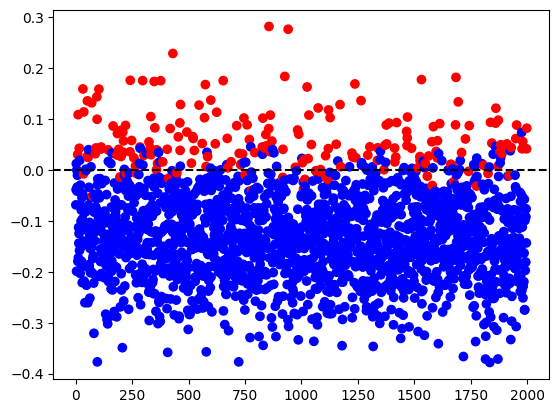

In [552]:
model_sqbc = GradSQBC()
model_sqbc.fit(X_train_01, y_train_01)
y_pred_sqbc = model_sqbc.predict_quantile(X_test_01)

plt.scatter(range(len(y_pred_sqbc)), y_pred_sqbc, c=y_test_01, cmap='bwr')  
plt.axhline(color='black', linestyle='--')

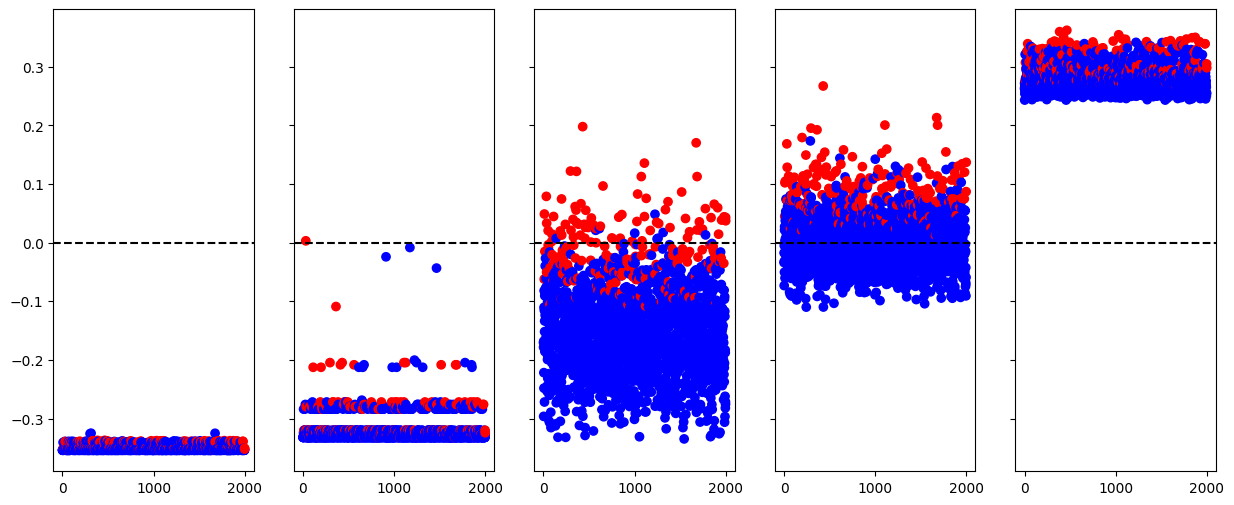

In [89]:
fig, axs = plt.subplots(1, 5, figsize=(15, 6),sharey=True)

for i, tau in enumerate([0.1, 0.3, 0.5, 0.7, 0.9]): 
 
    model_sqbc = SQBC(tau=tau)
    model_sqbc.fit(X_train_01, y_train_01)
    y_pred_sqbc = model_sqbc.predict_quantile(X_test_01)

    axs[i].scatter(range(len(y_pred_sqbc)), y_pred_sqbc, c=y_test_01, cmap='bwr')  
    axs[i].axhline(color='black', linestyle='--')


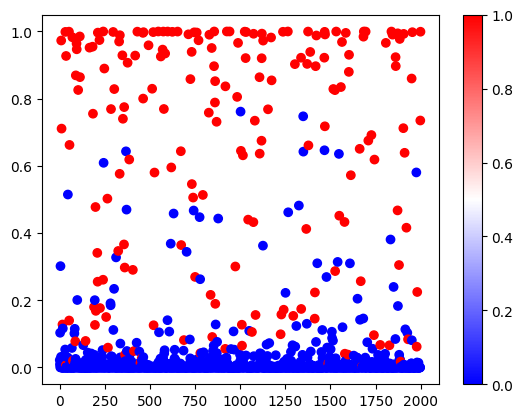

In [557]:
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train_01, y_train_01)
y_pred_xgb = model_xgb.predict_proba(X_test_01)[:,1]

plt.scatter(range(len(y_pred_xgb)), y_pred_xgb, c=y_test_01, cmap='bwr')  
plt.colorbar()  
plt.show()

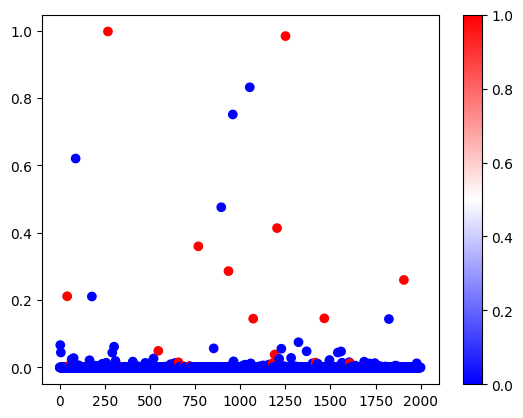

In [92]:
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train_001, y_train_001)
y_pred_xgb = model_xgb.predict_proba(X_test_001)[:,1]

plt.scatter(range(len(y_pred_xgb)), y_pred_xgb, c=y_test_001, cmap='bwr')  
plt.colorbar()  
plt.show()

In [ ]:
# Generate data
p = 0.1
X, y = generate_dataset(p=p)
X_train, X_test, y_train, y_test = cross_val_set(X, y)


# Fit models 

# SQBC tree
tau = 0.85
model_sqbc = SQBC(tau=tau)
model_sqbc.fit(X_train, y_train)
y_pred_sqbc = model_sqbc.predict(X_test)

# XGBoost
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print("SQBC:", evaluate(y_test, y_pred_sqbc))
print("XGBoost:", evaluate(y_test, y_pred_xgb))

In [ ]:
# Generate data
p = 0.05
X, y = generate_dataset(p=p)
X_train, X_test, y_train, y_test = cross_val_set(X, y)


# Fit models 

# SQBC tree
tau = 0.95
model_sqbc = SQBC(tau=tau)
model_sqbc.fit(X_train, y_train)
y_pred_sqbc = model_sqbc.predict(X_test)

# XGBoost
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print("SQBC:", evaluate(y_test, y_pred_sqbc))
print("XGBoost:", evaluate(y_test, y_pred_xgb))

# Plot confusion matrices 
cm_A = confusion_matrix(y_test, y_pred_sqbc, labels=[0, 1])
cm_B = confusion_matrix(y_test, y_pred_xgb, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

disp_A = ConfusionMatrixDisplay(confusion_matrix=cm_A, display_labels=[0, 1])
disp_A.plot(ax=axes[0], colorbar=False)

disp_B = ConfusionMatrixDisplay(confusion_matrix=cm_B, display_labels=[0, 1])
disp_B.plot(ax=axes[1], colorbar=False)

plt.tight_layout(rect=[0, 0.07, 1, 1]) 
plt.figtext(0.5, 0.01, f"Figure 4: Under strong class imbalance (p={p}), SQBC(left) with a high quantile level τ={tau} yields higher recall\n"
            "than standard XGBoost(right) by predicting more positives, at the expense of accuracy and specificity.", ha='center', fontsize=9)
plt.savefig("confusion_matrix.svg", format="svg")
plt.show()

## Estimate conditional variance

In [315]:
p = 0.5
X, y = generate_dataset(p=p)
X_train, X_test, y_train, y_test = cross_val_set(X, y)

In [330]:
# Assume you have q_low and q_high: predicted quantiles
tau_low, tau_high = 0.25, 0.75
z_low, z_high = norm.ppf(tau_low), norm.ppf(tau_high)

# Sample predictions
model_sqbc_low = SQBC(tau=tau_low)
model_sqbc_low.fit(X_train, y_train)
q_low = model_sqbc_low.predict_quantile(X_test)
model_sqbc_high = SQBC(tau=tau_high)
model_sqbc_high.fit(X_train, y_train)
q_high = model_sqbc_high.predict_quantile(X_test)

# Variance estimate
estimated_std = (q_high - q_low) / (z_high - z_low)
estimated_var = estimated_std**2


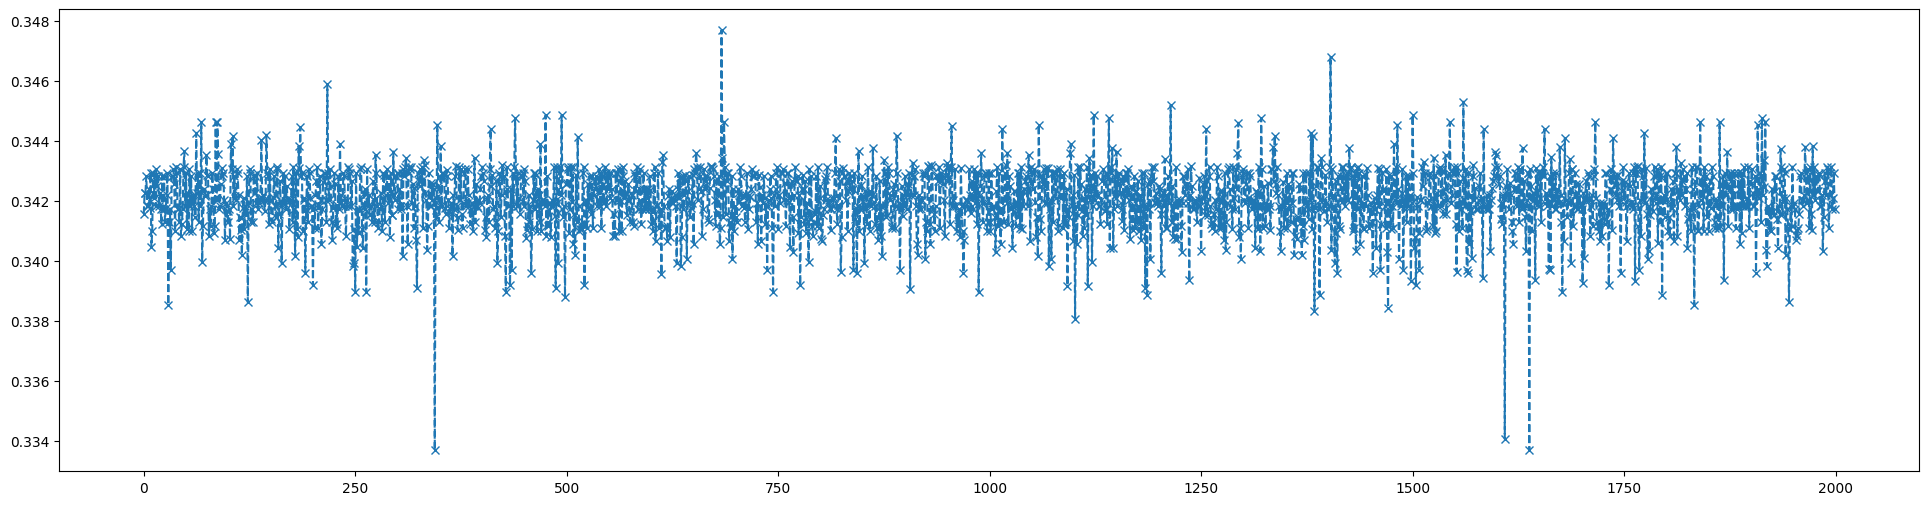

In [338]:
plt.figure(figsize=(24, 6))
plt.plot(estimated_std, 'x--')

## Plots

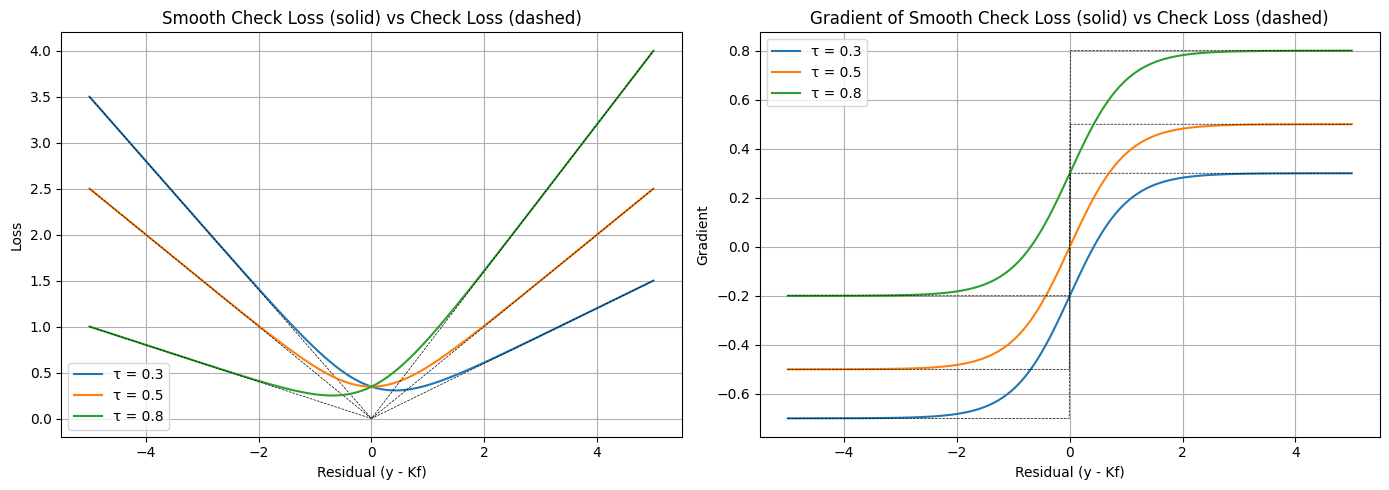

In [625]:
# Residuals
res = np.linspace(-5, 5, 500)
alpha = 0.5
taus = [0.3, 0.5, 0.8]

# Smooth check loss
def smooth_check(u, tau, alpha):
    return tau * u + alpha * np.log1p(np.exp(-u / alpha))

# Derivative of smooth check
def grad_smooth_check(u, tau, alpha):
    return - (1 / (1 + np.exp(u / alpha)) - tau)

# Non-smooth check loss
def check_loss(u, tau):
    return np.where(u >= 0, tau * u, (tau - 1) * u)

# Derivative of non-smooth check loss
def grad_check_loss(u, tau):
    return np.where(u >= 0, tau, tau - 1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tau in taus:
    # Smooth curves
    axes[0].plot(res, smooth_check(res, tau, alpha), label=f'τ = {tau}')
    axes[1].plot(res, grad_smooth_check(res, tau, alpha), label=f'τ = {tau}')
    
    # Non-smooth dashed curves (same color for all)
    axes[0].plot(res, check_loss(res, tau), linestyle='dashed', color='black', linewidth=0.5)
    axes[1].plot(res, grad_check_loss(res, tau), linestyle='dashed', color='black',linewidth=0.5)

# Labels and titles
axes[0].set_title("Smooth Check Loss (solid) vs Check Loss (dashed)")
axes[0].set_xlabel("Residual (y - Kf)")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Gradient of Smooth Check Loss (solid) vs Check Loss (dashed)")
axes[1].set_xlabel("Residual (y - Kf)")
axes[1].set_ylabel("Gradient")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [95]:
from sklearn.metrics import roc_curve

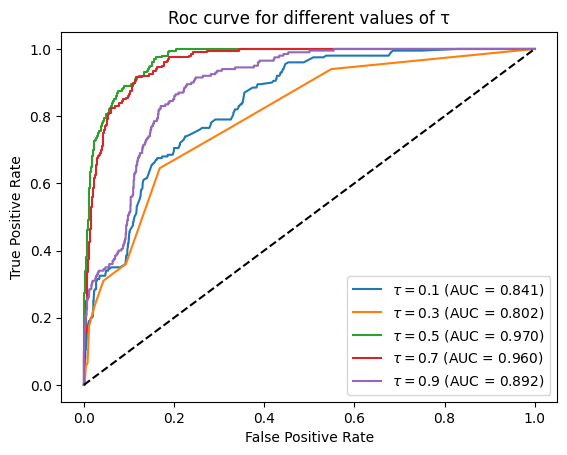

In [254]:
tau_range = [0.1, 0.3, 0.5, 0.7, 0.9]

for tau in tau_range: 

    sqbc = SQBC(tau=tau)
    sqbc.fit(X_train_01, y_train_01)

    scores = sqbc.predict_quantile(X_test_01)

    fpr, tpr, thresholds = roc_curve(y_test_01, scores)
    auc = roc_auc_score(y_test_01, scores)

    plt.plot(fpr, tpr, label=fr'$\tau={tau}$ (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc curve for different values of τ")
plt.legend()
plt.savefig("roc_curve.png", dpi=300, format="png")
plt.show()


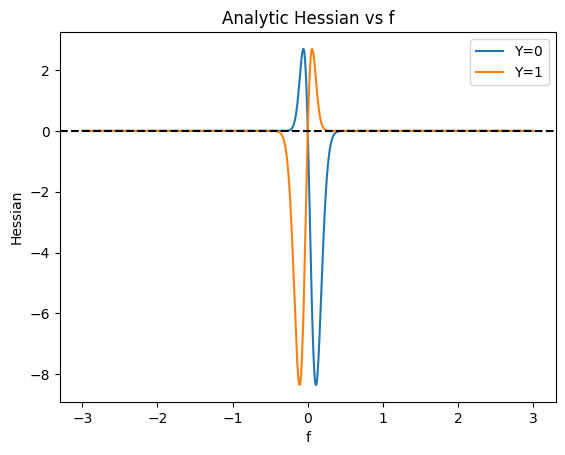

In [105]:
# params
h = 0.1
alpha = 0.5
tau = 0.5

def K(z): return norm.cdf(z)
def phi(z): return norm.pdf(z)

def hessian(f, Y):
    z = f / h
    Kfz = K(z)
    phiz = phi(z)
    L = np.exp((Y - Kfz) / alpha)  # L>0
    term1 = (f / h**3) * phiz * (tau - 1 / (1 + L))
    term2 = (1 / alpha) * ((f / h) * phiz)**2 * (L / (1 + L)**2)
    return term1 + term2

f_values = np.linspace(-3, 3, 1000)
for Y in (0, 1):
    hess_vals = [hessian(f, Y) for f in f_values]
    plt.plot(f_values, hess_vals, label=f'Y={Y}')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('f')
plt.ylabel('Hessian')
plt.legend()
plt.title('Analytic Hessian vs f')
plt.show()


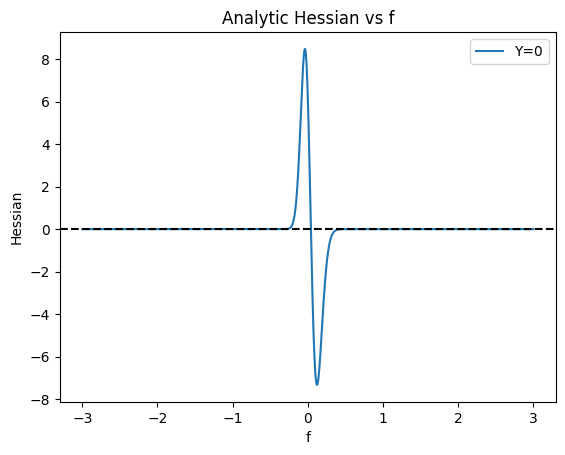

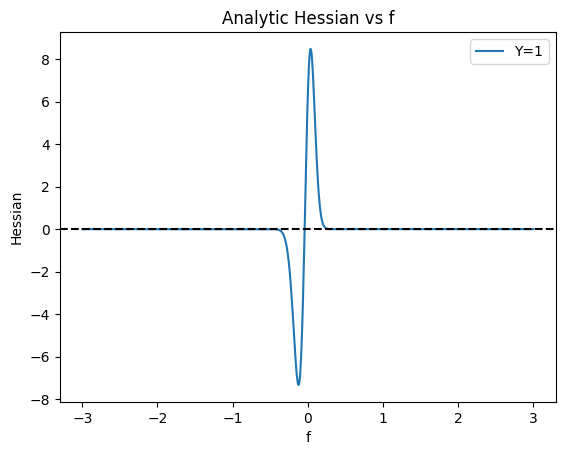

In [ ]:
# params
h = 0.1
alpha = 0.5
tau = 0.5


def hessian(f, Y):
        Kf = norm.cdf(f/h) 
        K_prime_f = norm.pdf(f/h) / h
        K_sec_f = -f/h**3 * norm.pdf(f/h)
        exp_term = np.exp((Y - Kf)/alpha)
        hess = -K_sec_f * (tau - 1 / (1 + exp_term)) + K_prime_f**2/alpha * exp_term/(1+exp_term)**2 
        return hess

f_values = np.linspace(-3, 3, 1000)
for Y in (0, 1):
        hess_vals = [hessian(f, Y) for f in f_values]
        plt.plot(f_values, hess_vals, label=f'Y={Y}')
        plt.axhline(0, color='k', linestyle='--')
        plt.xlabel('f')
        plt.ylabel('Hessian')
        plt.legend()
        plt.title('Analytic Hessian vs f')
        plt.show()
